# Mirror Game: Pose Dynamics Analysis

Full pipeline: Motion capture → Keypoint Extraction → CRQA → MdRQA → Statistical analysis

## 1. Setup & Data Loading

Load and prepare Mirror Game dataset with 3 experimental conditions:
- **b2b** (back-to-back): no visual feedback
- **uni** (unidirectional): one partner sees the other
- **f2f** (face-to-face): mutual visual feedback

In [39]:
import sys, os
from pathlib import Path

NB_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
REPO_ROOT = NB_DIR.parents[1]        # if examples/ is directly under repo root
SRC = REPO_ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from collections import defaultdict
from pose_dynamics.preprocessing import *
from pose_dynamics.geometry_utils import *
from pose_dynamics.io import *
from pose_dynamics.keypoint_utils import *
from pose_dynamics.normalization import *
from pose_dynamics.rqa.crossRQA import crossRQA  
from pose_dynamics.rqa.multivariateRQA import multivariateRQA


# Adjust DATA_DIR and OUT_DIR and go
DATA_DIR = REPO_ROOT / "data" / "Mirror"
OUT_DIR  = NB_DIR / "results"
OUT_DIR.mkdir(parents=True, exist_ok=True)


## 2. Temporal Alignment

Resample to 30 Hz, synchronize, and trim dyadic sequences to equal length.

In [40]:
TARGET_RATE    = 30.0 

MG_FILES = sorted(DATA_DIR.glob("*.csv"))
MG_RE = re.compile(r"^(P\d{3})_(T\d+)_((?:P1|P2))_pose_3d\.csv$", re.IGNORECASE)

index = defaultdict(dict)
bad = []

for f in MG_FILES:
    m = MG_RE.match(f.name)
    if not m:
        bad.append(f.name)
        continue
    pair_id, trial_id, party = (
        m.group(1).upper(), m.group(2).upper(), m.group(3).upper()
    )
    index[(pair_id, trial_id)][party] = f

print(f"Trials indexed: {len(index)} | Unparsed: {len(bad)}")
if bad[:5]:
    print("Unparsed sample:", bad[:5])

trial_groups = {}   # {(pair,trial): {'P1': (fname, df, cols), 'P2': (...)}}

for (pair_id, trial_id), parties in index.items():
    if "P1" not in parties or "P2" not in parties:
        continue

    f1, f2 = parties["P1"], parties["P2"]
    df1_raw = pd.read_csv(f1)
    df2_raw = pd.read_csv(f2)

    # 30 Hz resample using dt_ms
    df1 = resample(df1_raw, target_rate=TARGET_RATE)
    df2 = resample(df2_raw, target_rate=TARGET_RATE)

    # overlap + truncate to equal length
    df1_aligned, df2_aligned = align_pair(df1, df2)

    cols1 = order_xyz_triplets(df1_aligned.columns)
    cols2 = order_xyz_triplets(df2_aligned.columns)
    if not cols1 or not cols2:
        continue

    trial_groups[(pair_id, trial_id)] = {
        "P1": (f1.name, df1_aligned, cols1),
        "P2": (f2.name, df2_aligned, cols2),
    }

len(trial_groups)


Trials indexed: 216 | Unparsed: 2
Unparsed sample: ['rename_files.csv', 'rename_log.csv']


216

## 3. Spatial Alignment (Procrustes)

Center poses and build global template. Align all trials to canonical reference using Procrustes to remove position, scale, and orientation differences.

In [41]:
ALLOW_ROTATION = True   # currently not used by canonicalise_trial
ALLOW_SCALE    = False  # currently not used by canonicalise_trial
REF_IDX        = None    

# ---- Stage 1: center each trial (translation only) ----
trials = []     # list of (fname, df, cols)
centred = []    # list of flattened arrays (T, n_points*3)

for key, parties in trial_groups.items():
    for party in ("P1", "P2"):
        fname, df, cols = parties[party]
        trials.append((fname, df, cols))
        arr_flat, _meta = align_keypoints_3d(
            df,
            expected_cols=cols,
            ref_idx=REF_IDX,
            template=None,
            use_procrustes=False,   # first pass: centre only
            allow_rotation=False,
            allow_scale=False
        )
        centred.append(arr_flat)

if not trials:
    raise SystemExit("No usable trials after preprocessing.")

n_points = len(trials[0][2]) // 3

# ---- Stage 2: build a global canonical template ----
template = build_template_with_canonicalisation(centred, n_points)
print("Template shape:", template.shape)  # (n_points, 3)

# ---- Stage 3: apply canonicalisation (Procrustes) to each trial ----
canonicalised = []

for arr_flat in centred:
    T = arr_flat.shape[0]
    seq = arr_flat.reshape(T, n_points, 3)

    # canonicalise_trial currently always uses rotation, no scaling
    aligned_seq = canonicalise_trial(seq, template)

    canonicalised.append(aligned_seq.reshape(T, n_points * 3))

# from here on, use `centred` as the fully aligned sequences
centred = canonicalised

print("Canonicalisation complete for", len(centred), "trials.")


Template shape: (38, 3)
Canonicalisation complete for 432 trials.


## 4. Extract Keypoints
1. Map keypoint indices to interpretable anatomical labels
2. Select relevant keypoint subset for analysis
3. Perform quality control checks
4. Apply Butterworth filtering to remove noise
5. Generate visualization comparing raw vs filtered data

### Visualize Keypoints

In [18]:
from pose_dynamics.keypoint_viz import (
    plot_keypoints_interactive,
    plot_keypoints_with_indices_static,
    print_keypoint_table
)

# Print summary
print(f"Total keypoints: {len(template)}")
print(f"Keypoint shape: {template.shape}")
print("\n" + "="*70)

try:
    print("\nCreating interactive 3D visualization (hover over points to see details)...")
    fig = plot_keypoints_interactive(template, title="Mean Pose Template - Interactive Keypoint Indices")
except ImportError:
    print("\nplotly not available, using static matplotlib plots...")
    print("Install plotly for interactive plots: pip install plotly")
    plot_keypoints_with_indices_static(template, title="Mean Pose Template - Keypoint Indices")



Total keypoints: 38
Keypoint shape: (38, 3)


Creating interactive 3D visualization (hover over points to see details)...


### Define keypoint indices

In [42]:
# ============================================================================
# 4.1: DEFINE KEYPOINT MAPPING
# ============================================================================

#Map numeric indices to anatomical labels (MediaPipe Pose 38 keypoints)
KEYPOINT_MAPPING = {
    # Core body (0-4)
    0: 'pelvis',
    1: 'spine_1',
    2: 'spine_2',
    3: 'spine_3',
    4: 'neck',
    
    # Head (5-9)
    5: 'nose',
    6: 'left_eye',
    7: 'right_eye',
    8: 'left_ear',
    9: 'right_ear',
    
    # Shoulders/Clavicles (10-13)
    10: 'left_clavicle',
    11: 'right_clavicle',
    12: 'left_shoulder',
    13: 'right_shoulder',
    
    # Arms (14-17)
    14: 'left_elbow',
    15: 'right_elbow',
    16: 'left_wrist',
    17: 'right_wrist',
    
    # Hips/Legs (18-23)
    18: 'left_hip',
    19: 'right_hip',
    20: 'left_knee',
    21: 'right_knee',
    22: 'left_ankle',
    23: 'right_ankle',
    
    # Feet (24-29)
    24: 'left_big_toe',
    25: 'right_big_toe',
    26: 'left_small_toe',
    27: 'right_small_toe',
    28: 'left_heel',
    29: 'right_heel',
    
    # Left hand fingers (30-33)
    30: 'left_hand_thumb_4',
    31: 'right_hand_thumb_4',
    32: 'left_hand_index_1',
    33: 'right_hand_index_1',
    34: 'left_hand_middle_4',
    35: 'right_hand_middle_4',
    36: 'left_hand_pinky_1',
    37: 'right_hand_pinky_1',
}

print(f"✓ Defined mapping for {len(KEYPOINT_MAPPING)} keypoints")


✓ Defined mapping for 38 keypoints


In [43]:
# Define which keypoints to use for analysis
# Selected subset
# SELECTED_KEYPOINTS = [0, 1, 2, 3, 4, 5, 12, 13, 16, 17]  # Spine + head + shoulders + wrists

# Full body
SELECTED_KEYPOINTS = list(range(38))  # All keypoints

# Print selected keypoints with labels
print("Selected keypoints for analysis:")
for idx in SELECTED_KEYPOINTS:
    label = KEYPOINT_MAPPING.get(idx, f"point_{idx}")
    print(f"  {idx:2d}: {label}")

print(f"\n✓ Selected {len(SELECTED_KEYPOINTS)} keypoints "
      f"({len(SELECTED_KEYPOINTS)*3} dimensions)")

# Define connections between keypoints for skeleton visualization
# Based on MediaPipe Pose 38-keypoint model
SKELETON_EDGES = [
    # Spine
    (0, 1), (1, 2), (2, 3), (3, 4),  # Pelvis → Spine → Neck
    
    # Head
    (4, 5),  # Neck → Nose
    (5, 6), (5, 7),  # Nose → Eyes
    (6, 8), (7, 9),  # Eyes → Ears
    
    # Shoulders/Clavicles
    (4, 10), (4, 11),  # Neck → Clavicles
    (10, 12), (11, 13),  # Clavicles → Shoulders
    
    # Left arm
    (12, 14), (14, 16),  # Shoulder → Elbow → Wrist
    
    # Right arm
    (13, 15), (15, 17),  # Shoulder → Elbow → Wrist
    
    # Hips
    (0, 18), (0, 19),  # Pelvis → Hips
    
    # Left leg
    (18, 20), (20, 22),  # Hip → Knee → Ankle
    (22, 24), (22, 26),  # Ankle → Toes
    (22, 28),  # Ankle → Heel
    
    # Right leg
    (19, 21), (21, 23),  # Hip → Knee → Ankle
    (23, 25), (23, 27),  # Ankle → Toes
    (23, 29),  # Ankle → Heel
    
    # Left hand fingers (from wrist)
    (16, 30), (16, 32), (16, 34), (16, 36),
    
    # Right hand fingers (from wrist)
    (17, 31), (17, 33), (17, 35), (17, 37),
]

print(f"✓ Defined {len(SKELETON_EDGES)} skeleton connections")

BODY_REGIONS = {
    'head': {
        'indices': [5, 6, 7, 8, 9],
        'label': 'Head',
        'n_keypoints': 5
    },
    'arms': {
        'indices': [12, 13, 14, 15, 16, 17],
        'label': 'Arms', 
        'n_keypoints': 6
    },
    'legs': {
        'indices': [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29],
        'label': 'Legs',
        'n_keypoints': 12
    },
    'torso': {
        'indices': [0, 1, 2, 3, 4],
        'label': 'Torso',
        'n_keypoints': 5
    }
}

# make sure all region indices are actually in the selected subset
missing = {
    region: [i for i in info['indices'] if i not in SELECTED_KEYPOINTS]
    for region, info in BODY_REGIONS.items()
}
missing = {r: idxs for r, idxs in missing.items() if idxs}
if missing:
    raise ValueError(f"Region indices not in SELECTED_KEYPOINTS: {missing}")


Selected keypoints for analysis:
   0: pelvis
   1: spine_1
   2: spine_2
   3: spine_3
   4: neck
   5: nose
   6: left_eye
   7: right_eye
   8: left_ear
   9: right_ear
  10: left_clavicle
  11: right_clavicle
  12: left_shoulder
  13: right_shoulder
  14: left_elbow
  15: right_elbow
  16: left_wrist
  17: right_wrist
  18: left_hip
  19: right_hip
  20: left_knee
  21: right_knee
  22: left_ankle
  23: right_ankle
  24: left_big_toe
  25: right_big_toe
  26: left_small_toe
  27: right_small_toe
  28: left_heel
  29: right_heel
  30: left_hand_thumb_4
  31: right_hand_thumb_4
  32: left_hand_index_1
  33: right_hand_index_1
  34: left_hand_middle_4
  35: right_hand_middle_4
  36: left_hand_pinky_1
  37: right_hand_pinky_1

✓ Selected 38 keypoints (114 dimensions)
✓ Defined 37 skeleton connections


### Data Quality Check

In [44]:
# Run quality control on all trials
quality_reports = []

for (fname, df, cols), arr_flat in zip(trials, centred):
    trial_name = Path(fname).stem
    
    # Check data quality
    quality_report = check_data_quality(
        aligned_array=arr_flat,
        trial_name=trial_name,
        fps=TARGET_RATE,
        verbose=False  
    )
    
    quality_reports.append(quality_report)

# Summary statistics
n_total = len(quality_reports)
n_passed = sum(1 for qr in quality_reports if qr['passed'])
n_failed = n_total - n_passed

print("\n" + "="*80)
print("QUALITY CONTROL SUMMARY")
print("="*80)
print(f"Total trials:  {n_total}")
print(f"Passed:        {n_passed} ({100*n_passed/n_total:.1f}%)")
print(f"Failed:        {n_failed} ({100*n_failed/n_total:.1f}%)")

if n_failed > 0:
    print("\nFailed trials:")
    for qr in quality_reports:
        if not qr['passed']:
            print(f"  - {qr['trial_name']}")
            for issue in qr['issues']:
                print(f"      {issue}")




QUALITY CONTROL SUMMARY
Total trials:  432
Passed:        432 (100.0%)
Failed:        0 (0.0%)


In [45]:
# Extract selected keypoints from all trials
extracted_trials = []

for (fname, df, cols), arr_flat in zip(trials, centred):
    trial_name = Path(fname).stem
    
    # Extract subset of keypoints
    extracted = extract_keypoint_subset(
        aligned_array=arr_flat,
        keypoint_indices=SELECTED_KEYPOINTS
    )
    
    extracted_trials.append(extracted)
    
    #print(f"✓ {trial_name}: {arr_flat.shape} → {extracted.shape}")

print(f"\n✓ Extracted {len(SELECTED_KEYPOINTS)} keypoints from {len(extracted_trials)} trials")



✓ Extracted 38 keypoints from 432 trials


### Butterworth Filtering

In [46]:
# Filter parameters
FILTER_CUTOFF_HZ = 10  # 10 Hz captures voluntary human movement
FILTER_ORDER = 4       # 4th order provides good rolloff

print(f"Filter configuration:")
print(f"  Cutoff frequency: {FILTER_CUTOFF_HZ} Hz")
print(f"  Filter order:     {FILTER_ORDER}")
print(f"  Sampling rate:    {TARGET_RATE} Hz")
print(f"  Nyquist:          {TARGET_RATE/2} Hz")
print("-"*80)

# Apply filtering to all trials
filtered_trials = []
filter_params = []

for extracted, (fname, df, cols) in zip(extracted_trials, trials):
    trial_name = Path(fname).stem
    
    # Apply Butterworth filter
    filtered, filt_info = apply_butterworth_filter(
        aligned_array=extracted,
        fps=TARGET_RATE,
        cutoff_hz=FILTER_CUTOFF_HZ,
        order=FILTER_ORDER
    )
    
    filtered_trials.append(filtered)
    filter_params.append(filt_info)
    
    #print(f"✓ Filtered {trial_name}")

print(f"\n✓ Applied Butterworth filter to {len(filtered_trials)} trials")

# Create output directory for figures
FIG_DIR = OUT_DIR / "preprocessing_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Select keypoints to visualize (head, hand, foot for diversity)
VIZ_KEYPOINT_INDICES = [5, 16, 28]  # nose, left_wrist, left_heel
VIZ_KEYPOINT_LABELS = [KEYPOINT_MAPPING[idx] for idx in VIZ_KEYPOINT_INDICES]

print(f"Generating comparison plots for:")
for label, idx in zip(VIZ_KEYPOINT_LABELS, VIZ_KEYPOINT_INDICES):
    print(f"  - {label} (index {idx})")

# Generate comparison plot for first few trials
n_plots_to_generate = min(5, len(filtered_trials))

for i in range(n_plots_to_generate):
    trial_name = Path(trials[i][0]).stem
    
    # Generate comparison plot
    fig = plot_filtering_comparison(
        raw_array=extracted_trials[i],
        filtered_array=filtered_trials[i],
        fps=TARGET_RATE,
        keypoint_labels=VIZ_KEYPOINT_LABELS,
        keypoint_indices=VIZ_KEYPOINT_INDICES,
        save_path=FIG_DIR / f"{trial_name}_filtering_comparison.png"
    )
    
    plt.close(fig)

print(f"\n✓ Generated {n_plots_to_generate} comparison plots in {FIG_DIR}")


Filter configuration:
  Cutoff frequency: 10 Hz
  Filter order:     4
  Sampling rate:    30.0 Hz
  Nyquist:          15.0 Hz
--------------------------------------------------------------------------------

✓ Applied Butterworth filter to 432 trials
Generating comparison plots for:
  - nose (index 5)
  - left_wrist (index 16)
  - left_heel (index 28)
Saved filtering comparison to /Users/cartersale/Documents/Pose_Dynamics/projects/MirrorGame/results/preprocessing_figures/P001_T10_P1_pose_3d_filtering_comparison.png
Saved filtering comparison to /Users/cartersale/Documents/Pose_Dynamics/projects/MirrorGame/results/preprocessing_figures/P001_T10_P2_pose_3d_filtering_comparison.png
Saved filtering comparison to /Users/cartersale/Documents/Pose_Dynamics/projects/MirrorGame/results/preprocessing_figures/P001_T11_P1_pose_3d_filtering_comparison.png
Saved filtering comparison to /Users/cartersale/Documents/Pose_Dynamics/projects/MirrorGame/results/preprocessing_figures/P001_T11_P2_pose_3d_fil

### Animation Demo

In [20]:
# Select first trial for demo video
demo_trial_idx = 0
demo_duration_sec = 1  # Show first 10 seconds

# Create video
create_preprocessing_video(
    raw_array=extracted_trials[demo_trial_idx],
    filtered_array=filtered_trials[demo_trial_idx],
    fps=TARGET_RATE,
    keypoint_labels=VIZ_KEYPOINT_LABELS,
    keypoint_indices=VIZ_KEYPOINT_INDICES,
    skeleton_edges=SKELETON_EDGES,
    duration_sec=demo_duration_sec,
    save_path=OUT_DIR / "preprocessing_demo.mp4"
)

print(f"✓ Mapped {len(KEYPOINT_MAPPING)} keypoints to anatomical labels")
print(f"✓ Selected {len(SELECTED_KEYPOINTS)} keypoints for analysis")
print(f"✓ Quality control: {n_passed}/{n_total} trials passed")
print(f"✓ Extracted keypoint subsets: {len(extracted_trials)} trials")
print(f"✓ Applied Butterworth filter: {FILTER_CUTOFF_HZ} Hz cutoff, order {FILTER_ORDER}")
print("\nOutput data:")
print(f"  filtered_trials: List of {len(filtered_trials)} arrays")
print(f"  Array shape:     (T, {len(SELECTED_KEYPOINTS)*3}) = (time, xyz coordinates)")
print(f"  Data ready for:  RQA analysis (next step)")
print(f"\nQuality report saved in:")
print(f"  quality_reports: List of {len(quality_reports)} dicts")


✓ Saved preprocessing video to /Users/cartersale/Documents/Pose_Dynamics/projects/MirrorGame/results/preprocessing_demo.mp4
  Duration: 1s, FPS: 30.0, Frames: 30
✓ Mapped 38 keypoints to anatomical labels
✓ Selected 38 keypoints for analysis
✓ Quality control: 432/432 trials passed
✓ Extracted keypoint subsets: 432 trials
✓ Applied Butterworth filter: 10 Hz cutoff, order 4

Output data:
  filtered_trials: List of 432 arrays
  Array shape:     (T, 114) = (time, xyz coordinates)
  Data ready for:  RQA analysis (next step)

Quality report saved in:
  quality_reports: List of 432 dicts


## 5. Linear Features
Extract kinematic features (displacement, velocity, acceleration) from filtered
pose data to quantify movement characteristics across visual feedback conditions
and leader/follower roles.

### Define Features and Windowing Parameters

In [47]:
from pose_dynamics.linear_features_utils import (
    process_all_trials_linear_features,
    merge_with_conditions,
    collapse_windows_for_stats
)

print("Using body regions defined earlier (Step 4):")
for region_name, region_info in BODY_REGIONS.items():
    print(f"  {region_info['label']:8s}: {region_info['n_keypoints']:2d} keypoints "
          f"(indices: {region_info['indices'][:3]}...)")

total_keypoints = sum(r['n_keypoints'] for r in BODY_REGIONS.values())
print(f"\nTotal: {total_keypoints} keypoints across {len(BODY_REGIONS)} regions")

# Window parameters
WINDOW_DURATION_SEC = 30
WINDOW_OVERLAP_FRAC = 0
FPS = TARGET_RATE  # From earlier in notebook (30 Hz)

# Calculate derived values
WINDOW_FRAMES = int(WINDOW_DURATION_SEC * FPS)
STEP_FRAMES = int(WINDOW_FRAMES * (1 - WINDOW_OVERLAP_FRAC))

print(f"Windowing parameters:")
print(f"  Duration:       {WINDOW_DURATION_SEC} seconds")
print(f"  Overlap:        {WINDOW_OVERLAP_FRAC*100:.0f}%")
print(f"  Sampling rate:  {FPS} Hz")
print(f"  Window frames:  {WINDOW_FRAMES}")
print(f"  Step frames:    {STEP_FRAMES}")
print(f"  Step duration:  {STEP_FRAMES/FPS:.0f} seconds")

print("\n" + "="*80)
print("SANITY CHECK: ACTUAL TRIAL LENGTHS")
print("="*80)

trial_lengths = [arr.shape[0] for arr in filtered_trials]
min_len = min(trial_lengths)
max_len = max(trial_lengths)

print(f"Trial length (frames): min={min_len}, max={max_len}")
print(f"Trial length (sec):    min={min_len/FPS:.1f}, max={max_len/FPS:.1f}")
print(f"Window frames:         {WINDOW_FRAMES} ({WINDOW_FRAMES/FPS:.1f}s)")


Using body regions defined earlier (Step 4):
  Head    :  5 keypoints (indices: [5, 6, 7]...)
  Arms    :  6 keypoints (indices: [12, 13, 14]...)
  Legs    : 12 keypoints (indices: [18, 19, 20]...)
  Torso   :  5 keypoints (indices: [0, 1, 2]...)

Total: 28 keypoints across 4 regions
Windowing parameters:
  Duration:       30 seconds
  Overlap:        0%
  Sampling rate:  30.0 Hz
  Window frames:  900
  Step frames:    900
  Step duration:  30 seconds

SANITY CHECK: ACTUAL TRIAL LENGTHS
Trial length (frames): min=1035, max=1083
Trial length (sec):    min=34.5, max=36.1
Window frames:         900 (30.0s)


### Extract kinematic features (displacement, velocity, acceleration)

In [48]:
print("Extracting kinematic features:")
print("  - Displacement (frame-to-frame movement)")
print("  - Velocity (displacement per second)")
print("  - Acceleration (change in velocity)")
print("Aggregations per window:")
print("  - Mean (average magnitude)")
print("  - RMS (root mean square)")

# Create parallel list of (pair_trial, party) tuples matching filtered_trials
pair_trials = []

for (pair_id, trial_id), parties in trial_groups.items():
    for party in ('P1', 'P2'):
        pair_trial = f"{pair_id}_{trial_id}"
        pair_trials.append((pair_trial, party))

# Extract features
linear_features = process_all_trials_linear_features(
    filtered_trials=filtered_trials,
    pair_trials=pair_trials,
    keypoint_groups=BODY_REGIONS,
    window_frames=WINDOW_FRAMES,
    step_frames=STEP_FRAMES,
    fps=FPS,
    verbose=False
)

Extracting kinematic features:
  - Displacement (frame-to-frame movement)
  - Velocity (displacement per second)
  - Acceleration (change in velocity)
Aggregations per window:
  - Mean (average magnitude)
  - RMS (root mean square)


### Label with Conditions and Save Windowed Features

In [49]:
# Path to conditions file
CONDITIONS_CSV = "Mirror_Game_Conditions.csv"

print(f"Merging with conditions file: {CONDITIONS_CSV}")
print("Adding:")
print("  - Visual feedback condition (b2b, uni, f2f)")
print("  - Leader/Follower role assignment")
print("linear_features columns:\n", linear_features.columns.tolist())
print("linear_features_merged columns:\n", linear_features_merged.columns.tolist())

# Merge
linear_features_merged = merge_with_conditions(
    features_df=linear_features,
    conditions_csv=CONDITIONS_CSV,
    verbose=True
)

# Display sample with conditions
print("\nSample with conditions:")
sample_cols = ['Pair', 'Trial', 'Condition', 'Role', 'body_region', 
               'window_index', 'velocity_rms']
print(linear_features_merged[sample_cols].head(10))

# Save complete windowed data
output_path = OUT_DIR / "linear_features_windowed.csv"
linear_features_merged.to_csv(output_path, index=False)

print(f"✓ Saved windowed features to: {output_path}")
print(f"  Rows: {len(linear_features_merged)}")
print(f"  Columns: {len(linear_features_merged.columns)}")

Merging with conditions file: Mirror_Game_Conditions.csv
Adding:
  - Visual feedback condition (b2b, uni, f2f)
  - Leader/Follower role assignment
linear_features columns:
 ['window_index', 'start_frame', 'end_frame', 'start_time_sec', 'end_time_sec', 'body_region', 'displacement_mean', 'displacement_rms', 'velocity_mean', 'velocity_rms', 'acceleration_mean', 'acceleration_rms', 'pair_trial', 'party', 'trial_index']
linear_features_merged columns:
 ['window_index', 'start_frame', 'end_frame', 'start_time_sec', 'end_time_sec', 'body_region', 'displacement_mean', 'displacement_rms', 'velocity_mean', 'velocity_rms', 'acceleration_mean', 'acceleration_rms', 'pair_trial', 'party', 'trial_index', 'Pair', 'Trial', 'Condition', 'Leader', 'Role']

Merge summary:
  Rows before: 1728
  Rows after:  1728
  Conditions:  ['uni' 'f2f' 'b2b']
  Roles:       ['Follower' 'Leader']

Sample with conditions:
   Pair  Trial Condition      Role body_region  window_index  velocity_rms
0     1     10       uni

### Statistical Tests

In [50]:
print("Collapsing windows within (Pair, Trial, Condition, Role, body_region)")
print("Takes mean across all windows to create one value per combination")

# Collapse
linear_features_collapsed = collapse_windows_for_stats(
    merged_df=linear_features_merged,
    verbose=True
)

# Save collapsed data
output_path_collapsed = OUT_DIR / "linear_features_collapsed.csv"
linear_features_collapsed.to_csv(output_path_collapsed, index=False)

print(f"\n✓ Saved collapsed features to: {output_path_collapsed}")

import statsmodels.api as sm
import statsmodels.formula.api as smf

df = linear_features_collapsed.copy()

# Make factors categorical with clean ordering
df['Pair']       = df['Pair'].astype('category')
df['Role']       = df['Role'].astype('category')
df['body_region']= df['body_region'].astype('category')
df['Condition']  = pd.Categorical(df['Condition'],
                                  categories=['b2b', 'uni', 'f2f'],
                                  ordered=True)

# Mixed-effects model: random intercept for Pair
mixed_model = smf.mixedlm(
    "velocity_rms ~ Condition * Role * body_region",
    df,
    groups=df["Pair"]
)
mixed_result = mixed_model.fit()
print(mixed_result.summary())


Collapsing windows within (Pair, Trial, Condition, Role, body_region)
Takes mean across all windows to create one value per combination

Collapsed windows:
  Original rows:  1728
  Collapsed rows: 1728
  Average windows per group: 1.0

✓ Saved collapsed features to: /Users/cartersale/Documents/Pose_Dynamics/projects/MirrorGame/results/linear_features_collapsed.csv
                             Mixed Linear Model Regression Results
Model:                         MixedLM             Dependent Variable:             velocity_rms
No. Observations:              1728                Method:                         REML        
No. Groups:                    18                  Scale:                          0.0243      
Min. group size:               96                  Log-Likelihood:                 668.3632    
Max. group size:               96                  Converged:                      Yes         
Mean group size:               96.0                                                   

/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


### Figures

/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_38109/3295298046.py:76: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_38109/3295298046.py:127: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


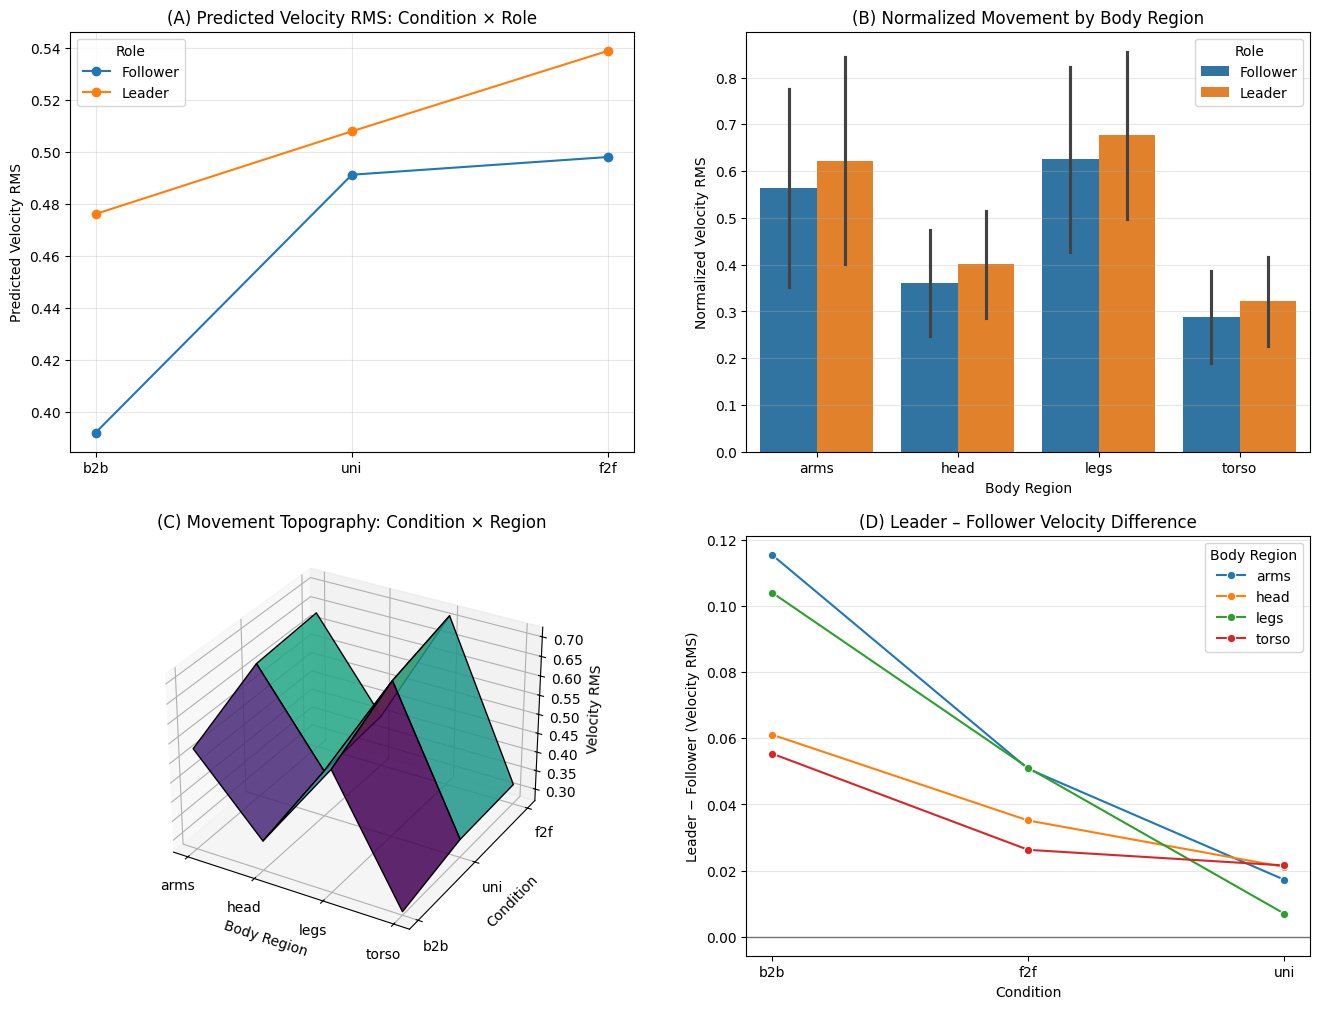

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

df = linear_features_collapsed.copy()

# -----------------------------------------
# Fit model for predicted means (A)
# -----------------------------------------
model_A = smf.ols(
    "velocity_rms ~ C(Condition) * C(Role)",
    data=df
).fit()

pred_df = pd.DataFrame(
    [(c, r) for c in df.Condition.unique() for r in df.Role.unique()],
    columns=["Condition", "Role"]
)
pred_df["yhat"] = model_A.predict(pred_df)


# -----------------------------------------
# Prepare normalized region data (B)
# -----------------------------------------
df_region = df.copy()
df_region["norm_velocity"] = (
    df_region.groupby("Pair")["velocity_rms"]
             .transform(lambda x: x / x.max())
)


# -----------------------------------------
# Prepare pivot for 3D surface (C)
# -----------------------------------------
pivot = df.pivot_table(
    values="velocity_rms",
    index="Condition",
    columns="body_region",
    aggfunc="mean"
).loc[["b2b","uni","f2f"]]  # ensure order


# -----------------------------------------
# Leader–Follower difference (D)
# -----------------------------------------
effect_df = (
    df.groupby(["Condition","body_region","Role"])["velocity_rms"]
      .mean().unstack()
)
effect_df["LeaderMinusFollower"] = (
    effect_df["Leader"] - effect_df["Follower"]
)

# -----------------------------------------
# Create 2x2 composite figure
# -----------------------------------------

fig = plt.figure(figsize=(16, 12))

# === (A) Predicted Means: Condition × Role ===
ax1 = fig.add_subplot(2, 2, 1)
for role in pred_df["Role"].unique():
    sub = pred_df[pred_df["Role"] == role]
    ax1.plot(sub["Condition"], sub["yhat"], marker="o", label=role)

ax1.set_title("(A) Predicted Velocity RMS: Condition × Role")
ax1.set_ylabel("Predicted Velocity RMS")
ax1.grid(alpha=0.3)
ax1.legend(title="Role")


# === (B) Normalized Body Region Profile ===
ax2 = fig.add_subplot(2, 2, 2)
sns.barplot(
    data=df_region,
    x="body_region",
    y="norm_velocity",
    hue="Role",
    ci="sd",
    ax=ax2
)
ax2.set_title("(B) Normalized Movement by Body Region")
ax2.set_ylabel("Normalized Velocity RMS")
ax2.set_xlabel("Body Region")
ax2.grid(axis="y", alpha=0.3)
ax2.legend(title="Role")


# === (C) 3D Surface: Condition × Region ===
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
X, Y = np.meshgrid(
    np.arange(len(pivot.columns)),
    np.arange(len(pivot.index))
)
Z = pivot.values

ax3.plot_surface(X, Y, Z, cmap="viridis", edgecolor="k", alpha=0.85)
ax3.set_xticks(np.arange(len(pivot.columns)))
ax3.set_xticklabels(pivot.columns)
ax3.set_yticks(np.arange(len(pivot.index)))
ax3.set_yticklabels(pivot.index)
ax3.set_xlabel("Body Region")
ax3.set_ylabel("Condition")
ax3.set_zlabel("Velocity RMS")
ax3.set_title("(C) Movement Topography: Condition × Region")


# === (D) Leader – Follower Difference ===
ax4 = fig.add_subplot(2, 2, 4)
sns.lineplot(
    data=effect_df.reset_index(),
    x="Condition",
    y="LeaderMinusFollower",
    hue="body_region",
    marker="o",
    ax=ax4
)
ax4.axhline(0, color="black", linewidth=1, alpha=0.5)
ax4.set_title("(D) Leader – Follower Velocity Difference")
ax4.set_ylabel("Leader − Follower (Velocity RMS)")
ax4.grid(axis="y", alpha=0.3)
ax4.legend(title="Body Region")


plt.tight_layout()
plt.show()


## 6. AMI and FNN

In [59]:
from pose_dynamics.nl_utils import (
    ami_average_across_features,
    fnn_average_across_features,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

all_rows = []
region_feature_map = {}   # region -> list of feature names

for (pair_trial, party), arr in zip(pair_trials, filtered_trials):
    # arr: (T, n_dims) for this recording
    T, D = arr.shape
    rec_id = f"{pair_trial}_{party}"
    
    df_trial = pd.DataFrame({
        "recording_id": rec_id,
        "frame": np.arange(T)
    })
    
    # For each region, for each keypoint index in that region
    for region_name, region_info in BODY_REGIONS.items():
        for kp_idx in region_info["indices"]:
            if kp_idx not in SELECTED_KEYPOINTS:
                continue  # skip if this kp wasn't included in the subset
            
            # column block for this keypoint in filtered_trials
            kp_pos = SELECTED_KEYPOINTS.index(kp_idx)
            col_start = 3 * kp_pos
            col_end = col_start + 3
            xyz = arr[:, col_start:col_end]   # (T, 3)
            
            # scalar series: magnitude, mean-centered
            mag = np.linalg.norm(xyz, axis=1)
            mag = mag - mag.mean()
            
            # feature name: region + keypoint label, safe for columns
            kp_label = KEYPOINT_MAPPING.get(kp_idx, f"kp{kp_idx}")
            safe_label = kp_label.replace(" ", "_")
            feat_name = f"{region_name}_{safe_label}"
            
            df_trial[feat_name] = mag
            region_feature_map.setdefault(region_name, []).append(feat_name)
    
    all_rows.append(df_trial)

df_all = pd.concat(all_rows, ignore_index=True)

# Deduplicate feature lists per region (in case of repeats)
for r in region_feature_map:
    region_feature_map[r] = sorted(sorted(set(region_feature_map[r])))

print(f"Built df_all for AMI/FNN with shape: {df_all.shape}")
print("Example columns:", df_all.columns[:10].tolist())
print("Region → #features:")
for r, feats in region_feature_map.items():
    print(f"  {r}: {len(feats)} keypoint features")


Built df_all for AMI/FNN with shape: (455138, 30)
Example columns: ['recording_id', 'frame', 'head_nose', 'head_left_eye', 'head_right_eye', 'head_left_ear', 'head_right_ear', 'arms_left_shoulder', 'arms_right_shoulder', 'arms_left_elbow']
Region → #features:
  head: 5 keypoint features
  arms: 6 keypoint features
  legs: 12 keypoint features
  torso: 5 keypoint features



STEP 6.2: AMI PER REGION / KEYPOINT
Doing AMI on 10 recordings per feature for: arms_left_elbow, arms_left_shoulder, arms_left_wrist, arms_right_elbow, arms_right_shoulder, arms_right_wrist, head_left_ear, head_left_eye, head_nose, head_right_ear, head_right_eye, legs_left_ankle, legs_left_big_toe, legs_left_heel, legs_left_hip, legs_left_knee, legs_left_small_toe, legs_right_ankle, legs_right_big_toe, legs_right_heel, legs_right_hip, legs_right_knee, legs_right_small_toe, torso_neck, torso_pelvis, torso_spine_1, torso_spine_2, torso_spine_3.


✓ Saved AMI figure: /Users/cartersale/Documents/Pose_Dynamics/projects/MirrorGame/results/ami_by_region_keypoint.png


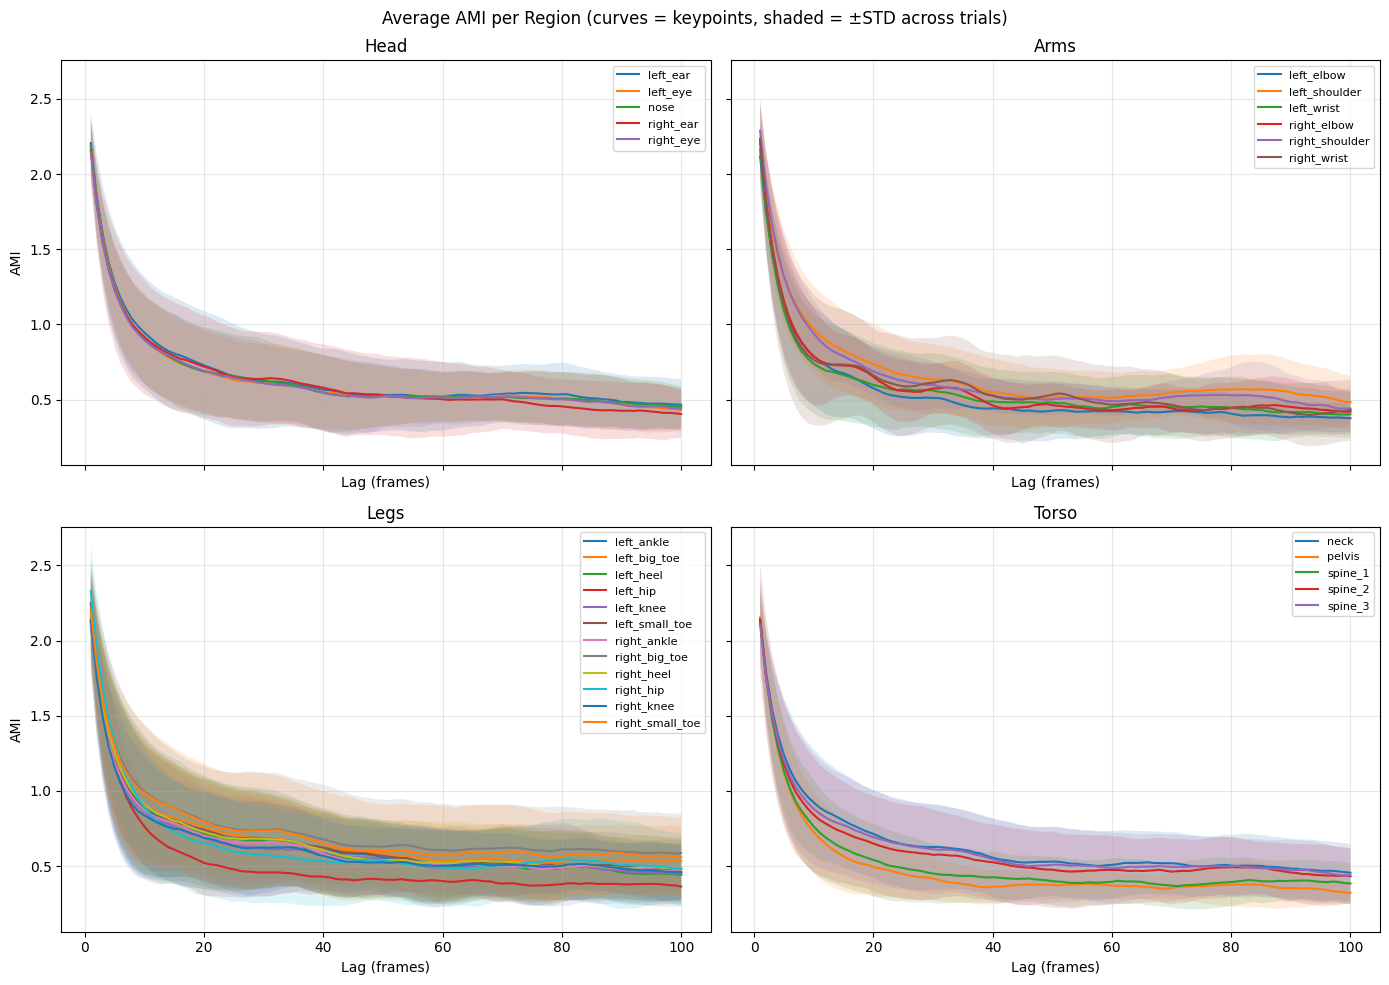

In [64]:
print("\n" + "="*80)
print("STEP 6.2: AMI PER REGION / KEYPOINT")
print("="*80)

# AMI configuration
MIN_LAG = 1
MAX_LAG = 100            
SAMPLE_N = 10       

# All features across all regions
all_features = sorted({f for feats in region_feature_map.values() for f in feats})

ami_results = ami_average_across_features(
    df_all=df_all,
    features=all_features,
    sample_n=SAMPLE_N,
    min_lag=MIN_LAG,
    max_lag=MAX_LAG,
    strategy="longest",
    seed=42,
    norm_kind=None,
    plot=False,          # we'll make our own plots
    verbose=True
)

# 2x2 subplot: one panel per region, curves = keypoints
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (region_name, region_info) in zip(axes, BODY_REGIONS.items()):
    feats = region_feature_map.get(region_name, [])
    if not feats:
        ax.set_visible(False)
        continue
    
    for feat_name in feats:
        avg_df = ami_results["per_feature_avg"].get(feat_name)
        curves_dict = ami_results["per_feature_curves"].get(feat_name, {})
        if avg_df is None or avg_df.empty or not curves_dict:
            continue
        
        lags = avg_df["lag"].to_numpy()
        mean = avg_df["ami_mean"].to_numpy()
        
        # recover STD across recordings: sem * sqrt(N)
        n_rec = len(curves_dict)
        std = avg_df["ami_sem"].to_numpy() * np.sqrt(max(n_rec, 1))
        
        # label = keypoint name without region prefix
        label = feat_name.split("_", 1)[1] if "_" in feat_name else feat_name
        
        ax.plot(lags, mean, label=label)
        ax.fill_between(lags, mean - std, mean + std, alpha=0.15)
    
    ax.set_title(region_info["label"])
    ax.grid(alpha=0.3)
    ax.set_xlabel("Lag (frames)")
    # Determine subplot index
    ax_idx = list(axes).index(ax)

    # Left column → set y-label
    if ax_idx in [0, 2]:
        ax.set_ylabel("AMI")

    ax.legend(fontsize=8)
    
fig.suptitle("Average AMI per Region (curves = keypoints, shaded = ±STD across trials)", y=0.98)
plt.tight_layout()
plt.savefig(OUT_DIR / "ami_by_region_keypoint.png", dpi=150)
print(f"✓ Saved AMI figure: {OUT_DIR / 'ami_by_region_keypoint.png'}")



FNN summary:
   [arms_left_elbow] 10 rec(s); dims 1..15
   [arms_left_shoulder] 10 rec(s); dims 1..15
   [arms_left_wrist] 10 rec(s); dims 1..15
   [arms_right_elbow] 10 rec(s); dims 1..15
   [arms_right_shoulder] 10 rec(s); dims 1..15
   [arms_right_wrist] 10 rec(s); dims 1..15
   [head_left_ear] 10 rec(s); dims 1..15
   [head_left_eye] 10 rec(s); dims 1..15
   [head_nose] 10 rec(s); dims 1..15
   [head_right_ear] 10 rec(s); dims 1..15
   [head_right_eye] 10 rec(s); dims 1..15
   [legs_left_ankle] 10 rec(s); dims 1..15
   [legs_left_big_toe] 10 rec(s); dims 1..15
   [legs_left_heel] 10 rec(s); dims 1..15
   [legs_left_hip] 10 rec(s); dims 1..15
   [legs_left_knee] 10 rec(s); dims 1..15
   [legs_left_small_toe] 10 rec(s); dims 1..15
   [legs_right_ankle] 10 rec(s); dims 1..15
   [legs_right_big_toe] 10 rec(s); dims 1..15
   [legs_right_heel] 10 rec(s); dims 1..15
   [legs_right_hip] 10 rec(s); dims 1..15
   [legs_right_knee] 10 rec(s); dims 1..15
   [legs_right_small_toe] 10 rec(s); d

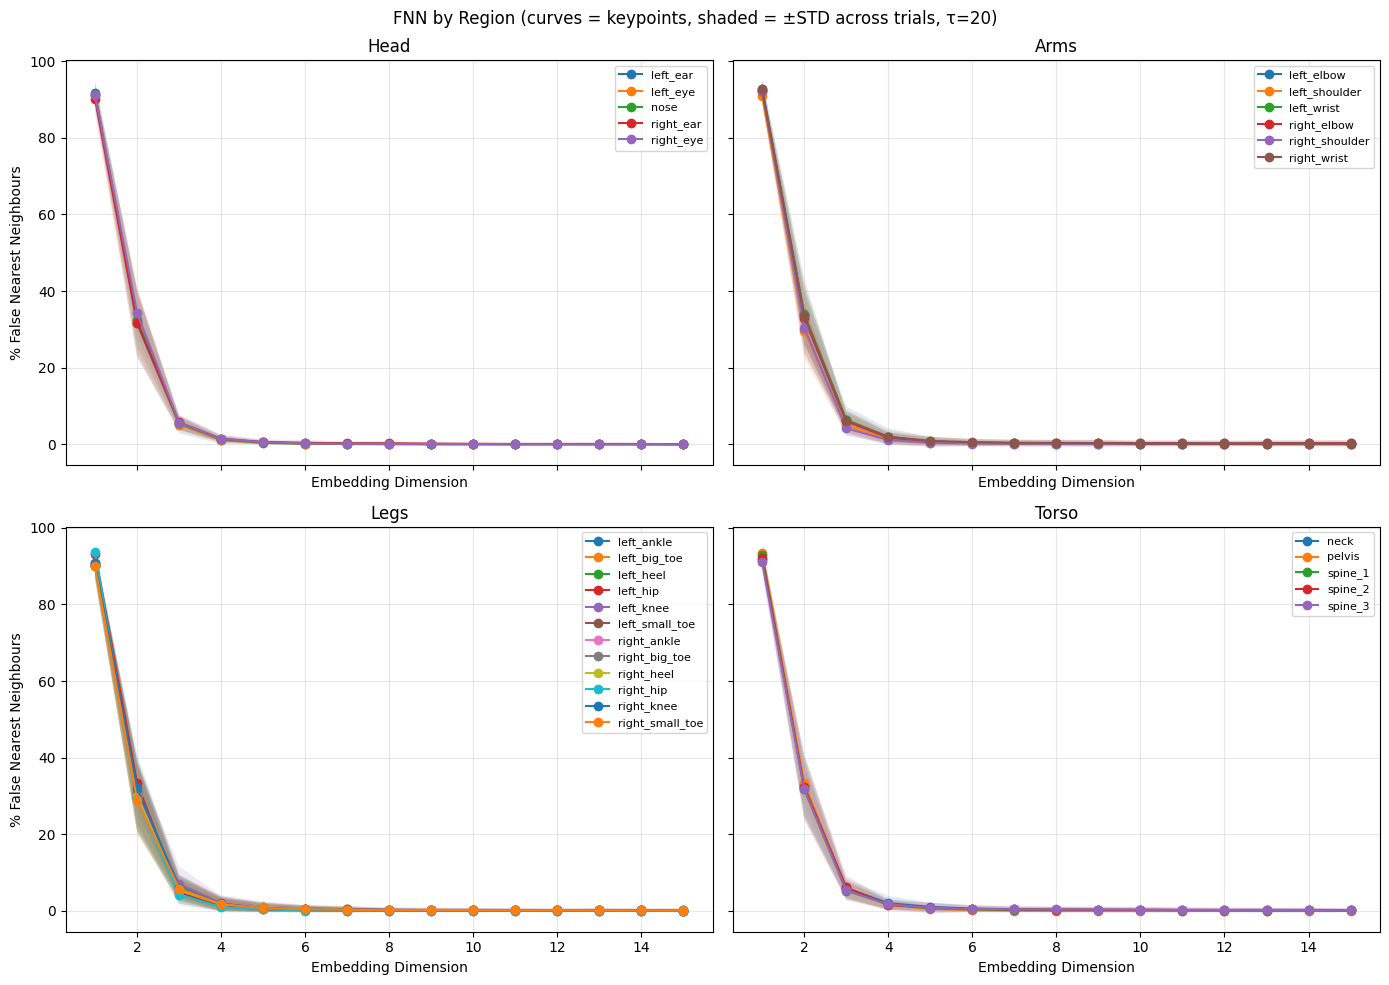

In [67]:
from pose_dynamics.nl_utils import fnn_average_across_features

tau = 20 # from AMI results

MIN_DIM = 1
MAX_DIM = 15
SAMPLE_N_FNN = 10   # effectively 'all recordings', limited by fnn function

# all features from all regions
all_features = sorted({f for feats in region_feature_map.values() for f in feats})

fnn_results = fnn_average_across_features(
    df_all=df_all,
    features=all_features,
    tau=tau,
    min_dim=MIN_DIM,
    max_dim=MAX_DIM,
    sample_n=SAMPLE_N_FNN,
    strategy="longest",
    seed=42,
    plot=False,          
    title_suffix=f"τ={tau}"
)

per_feature_avg    = fnn_results["per_feature_avg"]
per_feature_curves = fnn_results["per_feature_curves"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (region_name, region_info) in zip(axes, BODY_REGIONS.items()):
    feats = region_feature_map.get(region_name, [])
    if not feats:
        ax.set_visible(False)
        continue
    
    for feat_name in feats:
        avg_df = per_feature_avg.get(feat_name)
        curves = per_feature_curves.get(feat_name, [])
        if avg_df is None or avg_df.empty or not curves:
            continue
        
        dims = avg_df["dim"].to_numpy()
        mean = avg_df["fnn_mean"].to_numpy()
        
        # recover STD across recordings from SEM
        n_rec = len(curves)
        std = avg_df["fnn_sem"].to_numpy() * np.sqrt(max(n_rec, 1))
        
        # label = keypoint part of the name (strip region prefix)
        label = feat_name.split("_", 1)[1] if "_" in feat_name else feat_name
        
        ax.plot(dims, mean, marker="o", label=label)
        ax.fill_between(dims, mean - std, mean + std, alpha=0.15)
    
    ax.set_title(region_info["label"])
    ax.grid(alpha=0.3)
    ax.set_xlabel("Embedding Dimension")
    
    # left column axes (0, 2) get y-label
    ax_idx = list(axes).index(ax)
    if ax_idx in [0, 2]:
        ax.set_ylabel("% False Nearest Neighbours")
    
    ax.legend(fontsize=8)

fig.suptitle(f"FNN by Region (curves = keypoints, shaded = ±STD across trials, τ={tau})", y=0.98)
plt.tight_layout()
out_path = OUT_DIR / "fnn_by_region_keypoint.png"
plt.savefig(out_path, dpi=150)
print(f"✓ Saved FNN figure: {out_path}")


## 7. Cross-Recurrence Quantification (CRQA)

Quantify dyadic coordination using CRQA metrics:
- **%REC**: Recurrence rate (how often similar states occur)
- **%DET**: Determinism (structure/predictability)
- **Entropy**, **Laminarity**, **Trapping Time**: Pattern complexity and persistence

### Main Analysis

In [ ]:
from collections import defaultdict
from pose_dynamics.rqa.crossRQA import crossRQA


TARGET_KP_NAMES = [
    "nose",
    "left_wrist",
    "right_wrist",
    "left_ankle",
    "right_ankle",
    "spine_1",
]

# Map names → indices using KEYPOINT_MAPPING
name_to_idx = {}
for idx, name in KEYPOINT_MAPPING.items():
    if name in TARGET_KP_NAMES:
        name_to_idx[name] = idx

missing = [n for n in TARGET_KP_NAMES if n not in name_to_idx]
if missing:
    raise ValueError(f"These target keypoints are not in KEYPOINT_MAPPING: {missing}")

print("Using keypoints:")
for n in TARGET_KP_NAMES:
    print(f"  {n}: index {name_to_idx[n]}")

# Build list of scalar signals
kp_signals = []   # each item: {'pair_trial', 'party', 'kp_name', 'signal'}

for (pair_trial, party), arr in zip(pair_trials, filtered_trials):
    T, D = arr.shape
    
    for kp_name in TARGET_KP_NAMES:
        kp_idx = name_to_idx[kp_name]
        if kp_idx not in SELECTED_KEYPOINTS:
            continue  # this keypoint not kept in the subset
        
        kp_pos = SELECTED_KEYPOINTS.index(kp_idx)
        start = 3 * kp_pos
        xyz = arr[:, start:start+3]   # (T, 3)
        
        mag = np.linalg.norm(xyz, axis=1)
        mag = mag - mag.mean()        # mean-center
        
        kp_signals.append({
            "pair_trial": pair_trial,
            "party": party,
            "kp_name": kp_name,
            "signal": mag
        })

print(f"Built {len(kp_signals)} keypoint time series for CRQA.")

paired_kp = defaultdict(dict)  # (pair_trial, kp_name) -> {'P1': sig, 'P2': sig}

for entry in kp_signals:
    key = (entry["pair_trial"], entry["kp_name"])
    paired_kp[key][entry["party"]] = entry["signal"]

n_pairs = sum(1 for k, v in paired_kp.items() if "P1" in v and "P2" in v)
print(f"Found {n_pairs} usable P1–P2 pairs across keypoints.")



Using keypoints:
  nose: index 5
  left_wrist: index 16
  right_wrist: index 17
  left_ankle: index 22
  right_ankle: index 23
  spine_1: index 1
Built 2592 keypoint time series for CRQA.
Found 1296 usable P1–P2 pairs across keypoints.


In [109]:
RADIUS_BY_KEYPOINT = {
    "nose":        0.27,
    "left_wrist":  0.20,
    "right_wrist": 0.23,
    "left_ankle":  0.23,
    "right_ankle": 0.23,
    "spine_1":     0.33,
}

m = 4
tau = 20
minl = 3

CRQA_RESULTS = []

for (pair_trial, kp_name), parties in paired_kp.items():
    if "P1" not in parties or "P2" not in parties:
        continue
    
    # pull selected radius for this keypoint
    if kp_name not in RADIUS_BY_KEYPOINT:
        print(f"⚠️ No radius defined for keypoint '{kp_name}'. Skipping.")
        continue

    rad = float(RADIUS_BY_KEYPOINT[kp_name])
    
    sig1 = parties["P1"]
    sig2 = parties["P2"]
    
    # Ensure equal length
    T = min(len(sig1), len(sig2))
    sig1_use = sig1[:T]
    sig2_use = sig2[:T]
    
    params = {
        "norm":        "zscore",
        "eDim":        m,
        "tLag":        tau,
        "rescaleNorm": 1,
        "radius":      rad,
        "tmin":        0,
        "minl":        minl,
        "doPlots":     False,
        "plotMode":    "none",
        "phaseSpace":  "time",
        "showMetrics": False,
        "pointSize":   1,
        "saveFig":     False,
        "doStatsFile": False,
    }
    
    td, rs, mats, err_code = crossRQA(sig1_use, sig2_use, params)
    
    if err_code != 0:
        print(f"⚠️ CRQA error for {pair_trial}, {kp_name} (err={err_code})")
        continue
    
    # Flatten rs
    rs_flat = {k: float(v) for k, v in rs.items()}
    CRQA_RESULTS.append({
        "pair_trial": pair_trial,
        "keypoint": kp_name,
        "radius": rad,
        **rs_flat
    })

print(f"\n✓ Finished CRQA for {len(CRQA_RESULTS)} keypoint×pair combinations.")

crqa_df = pd.DataFrame(CRQA_RESULTS)
crqa_out = OUT_DIR / "crqa_selected_keypoints.csv"
crqa_df.to_csv(crqa_out, index=False)
print(f"✓ Saved CRQA results to {crqa_out}")



✓ Finished CRQA for 1296 keypoint×pair combinations.
✓ Saved CRQA results to /Users/cartersale/Documents/Pose_Dynamics/projects/MirrorGame/results/crqa_selected_keypoints.csv


### CRQA Radius Sweep and Effects Interaction


CRQA RADIUS SWEEP: SELECTED KEYPOINTS
Using keypoints:
  nose: index 5
  left_wrist: index 16
  right_wrist: index 17
  left_ankle: index 22
  right_ankle: index 23
  spine_1: index 1

Built 2592 keypoint time series.
Found 1296 usable P1–P2 pairs across keypoints.

Sweeping 10 radius values for each keypoint...
Radii: [0.1   0.133 0.167 0.2   0.233 0.267 0.3   0.333 0.367 0.4  ]

Keypoint nose: using 10 pairs for sweep.

Keypoint left_wrist: using 10 pairs for sweep.

Keypoint right_wrist: using 10 pairs for sweep.

Keypoint left_ankle: using 10 pairs for sweep.

Keypoint right_ankle: using 10 pairs for sweep.

Keypoint spine_1: using 10 pairs for sweep.

✓ Saved CRQA radius sweep heatmap to: /Users/cartersale/Documents/Pose_Dynamics/projects/MirrorGame/results/crqa_radius_sweep_heatmap.png


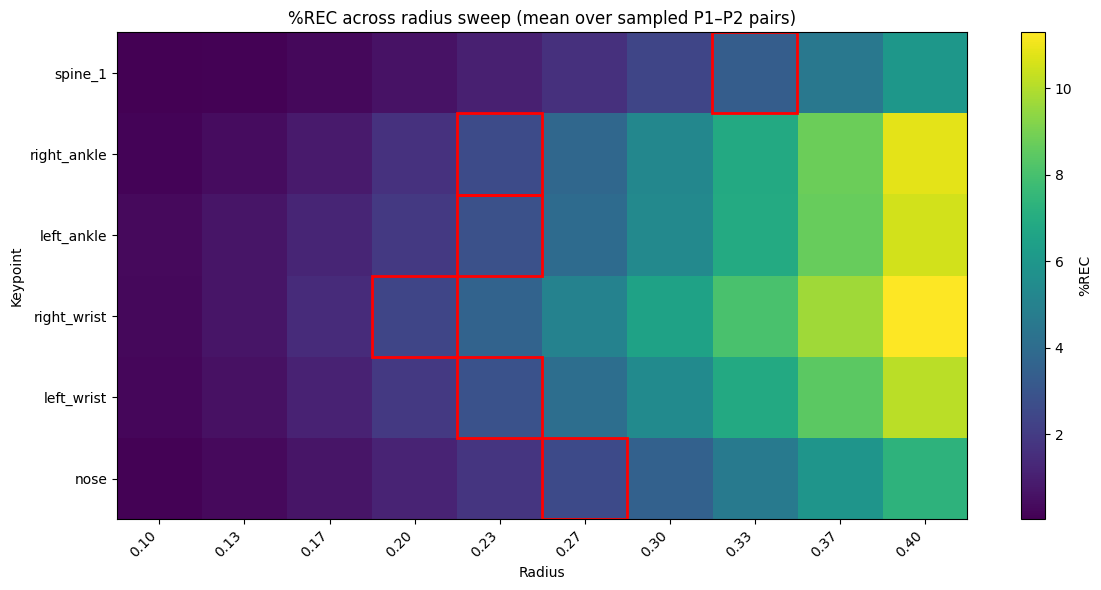

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.patches import Rectangle
from pose_dynamics.rqa.crossRQA import crossRQA

print("\n" + "="*80)
print("CRQA RADIUS SWEEP: SELECTED KEYPOINTS")
print("="*80)

# ---------------------------------------------------------------------
# 1. Define keypoints and map names -> indices
# ---------------------------------------------------------------------
TARGET_KP_NAMES = [
    "nose",
    "left_wrist",
    "right_wrist",
    "left_ankle",
    "right_ankle",
    "spine_1",
]

name_to_idx = {}
for idx, name in KEYPOINT_MAPPING.items():
    if name in TARGET_KP_NAMES:
        name_to_idx[name] = idx

missing = [n for n in TARGET_KP_NAMES if n not in name_to_idx]
if missing:
    raise ValueError(f"Missing keypoints in KEYPOINT_MAPPING: {missing}")

print("Using keypoints:")
for n in TARGET_KP_NAMES:
    print(f"  {n}: index {name_to_idx[n]}")

# ---------------------------------------------------------------------
# 2. Build scalar signals per keypoint per trial/party
# ---------------------------------------------------------------------
kp_signals = []   # each item: {'pair_trial','party','kp_name','signal'}

for (pair_trial, party), arr in zip(pair_trials, filtered_trials):
    T, D = arr.shape
    
    for kp_name in TARGET_KP_NAMES:
        kp_idx = name_to_idx[kp_name]
        if kp_idx not in SELECTED_KEYPOINTS:
            continue
        
        kp_pos = SELECTED_KEYPOINTS.index(kp_idx)
        start = 3 * kp_pos
        xyz = arr[:, start:start+3]  # (T, 3)
        
        mag = np.linalg.norm(xyz, axis=1)
        mag = mag - mag.mean()
        
        kp_signals.append({
            "pair_trial": pair_trial,
            "party":      party,
            "kp_name":    kp_name,
            "signal":     mag
        })

print(f"\nBuilt {len(kp_signals)} keypoint time series.")

# ---------------------------------------------------------------------
# 3. Pair P1–P2 signals for each keypoint
# ---------------------------------------------------------------------
paired_kp = defaultdict(dict)  # (pair_trial, kp_name) -> {'P1': sig, 'P2': sig}

for entry in kp_signals:
    key = (entry["pair_trial"], entry["kp_name"])
    paired_kp[key][entry["party"]] = entry["signal"]

n_pairs_total = sum(1 for _, v in paired_kp.items() if "P1" in v and "P2" in v)
print(f"Found {n_pairs_total} usable P1–P2 pairs across keypoints.")

# ---------------------------------------------------------------------
# 4. Radius sweep setup
# ---------------------------------------------------------------------
m   = 4
tau = 20

RADIUS_VALUES = np.linspace(0.1, 0.4, 10)  # tweak if you want
MAX_PAIRS_PER_KP = 10                       # limit compute per keypoint

heatmap_vals = np.full((len(TARGET_KP_NAMES), len(RADIUS_VALUES)), np.nan)

print(f"\nSweeping {len(RADIUS_VALUES)} radius values for each keypoint...")
print("Radii:", np.round(RADIUS_VALUES, 3))

# ---------------------------------------------------------------------
# 5. Run CRQA for each keypoint × radius, average %REC
# ---------------------------------------------------------------------
for i, kp_name in enumerate(TARGET_KP_NAMES):
    # gather all pair_trials for this keypoint
    keys_for_kp = [k for k in paired_kp.keys() if k[1] == kp_name and
                   "P1" in paired_kp[k] and "P2" in paired_kp[k]]
    
    if not keys_for_kp:
        print(f"⚠️ No P1–P2 pairs for keypoint {kp_name}")
        continue
    
    # sample a subset if there are many
    keys_for_kp = keys_for_kp[:MAX_PAIRS_PER_KP]
    print(f"\nKeypoint {kp_name}: using {len(keys_for_kp)} pairs for sweep.")
    
    for j, rad in enumerate(RADIUS_VALUES):
        rec_vals = []
        
        for (pair_trial, _kp) in keys_for_kp:
            sig1 = paired_kp[(pair_trial, kp_name)]["P1"]
            sig2 = paired_kp[(pair_trial, kp_name)]["P2"]
            
            T = min(len(sig1), len(sig2))
            sig1_use = sig1[:T]
            sig2_use = sig2[:T]
            
            params = {
                "norm":        2,
                "eDim":        m,
                "tLag":        tau,
                "rescaleNorm": 1,  # rescale distances
                "radius":      float(rad),
                "tmin":        0,
                "minl":        2,
                "doPlots":     False,
                "plotMode":    "none",
                "phaseSpace":  "time",
                "showMetrics": False,
                "pointSize":   1,
                "saveFig":     False,
                "doStatsFile": False,
            }
            
            td, rs, mats, err = crossRQA(sig1_use, sig2_use, params)
            if err == 0 and "perc_recur" in rs:
                rec_vals.append(float(rs["perc_recur"]))
        
        if rec_vals:
            heatmap_vals[i, j] = np.mean(rec_vals)

# ---------------------------------------------------------------------
# 6. Plot heatmap: y = keypoint, x = radius, color = %REC
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(
    heatmap_vals,
    aspect="auto",
    origin="lower",
    interpolation="nearest"
)

# X-axis: radii
ax.set_xticks(np.arange(len(RADIUS_VALUES)))
ax.set_xticklabels([f"{r:.2f}" for r in RADIUS_VALUES], rotation=45, ha="right")

# Y-axis: keypoints
ax.set_yticks(np.arange(len(TARGET_KP_NAMES)))
ax.set_yticklabels(TARGET_KP_NAMES)

ax.set_xlabel("Radius")
ax.set_ylabel("Keypoint")
ax.set_title("%REC across radius sweep (mean over sampled P1–P2 pairs)")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("%REC")

# ---------------------------------------------------------------------
# 6b. Highlight, for each keypoint, the cell whose %REC is closest to 3%
# ---------------------------------------------------------------------
TARGET_REC = 3.0  # assuming rs["perc_recur"] is in percentage units

for i in range(len(TARGET_KP_NAMES)):
    row = heatmap_vals[i, :]

    # skip keypoints with no data
    if np.all(np.isnan(row)):
        continue

    # index of radius whose %REC is closest to 3%
    j = np.nanargmin(np.abs(row - TARGET_REC))

    # draw a red box around that cell
    rect = Rectangle(
        (j - 0.5, i - 0.5),  # bottom-left corner (x, y)
        1,                   # width (1 cell)
        1,                   # height (1 cell)
        fill=False,
        edgecolor="red",
        linewidth=2
    )
    ax.add_patch(rect)

plt.tight_layout()
out_path = OUT_DIR / "crqa_radius_sweep_heatmap.png"
plt.savefig(out_path, dpi=150)
print(f"\n✓ Saved CRQA radius sweep heatmap to: {out_path}")

/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_38109/98570977.py:66: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


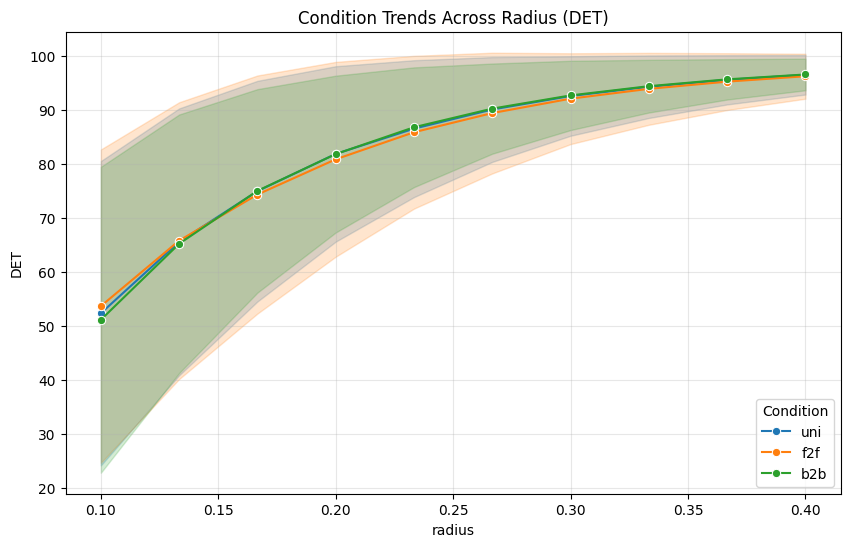

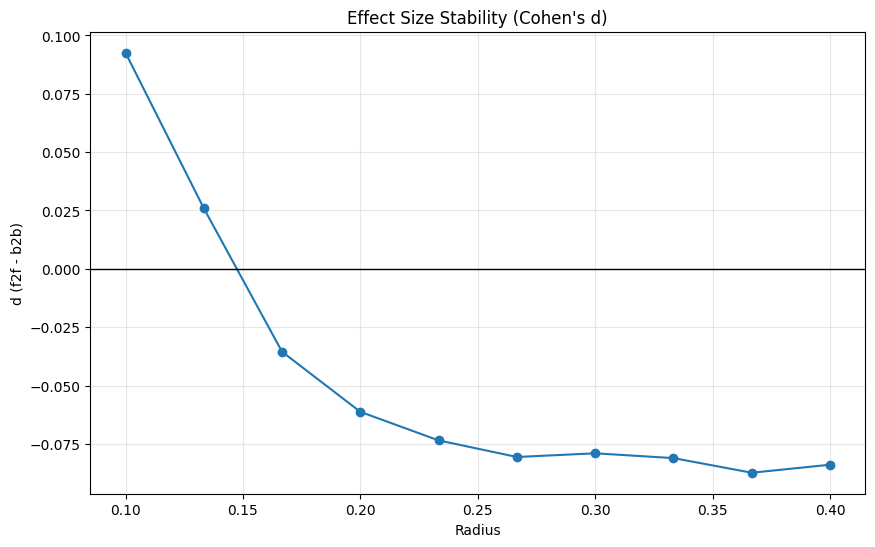

In [ ]:
import numpy as np
import pandas as pd
from pose_dynamics.rqa.crossRQA import crossRQA
import matplotlib.pyplot as plt
import seaborn as sns

RADII = np.linspace(0.10, 0.40, 10) # radius values to test

TREND_RESULTS = []  

kp_name = "right_wrist"  # choose signal

keys_for_kp = [
    k for k in paired_kp.keys()
    if k[1] == kp_name and "P1" in paired_kp[k] and "P2" in paired_kp[k]
]

for rad in RADII:
    for (pair_trial, _kp) in keys_for_kp:
        sig1 = paired_kp[(pair_trial, kp_name)]["P1"]
        sig2 = paired_kp[(pair_trial, kp_name)]["P2"]
        
        T = min(len(sig1), len(sig2))
        s1, s2 = sig1[:T], sig2[:T]
        
        params = {
            "norm": "zscore",
            "eDim": 4,
            "tLag": 20,
            "rescaleNorm": 1,   
            "radius": float(rad),
            "tmin": 0,
            "minl": 2,
            "doPlots": False,
            "plotMode": "none",
            "showMetrics": False,
            "saveFig": False,
            "doStatsFile": False,
        }
        
        td, rs, mats, err = crossRQA(s1, s2, params)
        if err == 0:
            TREND_RESULTS.append({
                "pair_trial": pair_trial,
                "radius": rad,
                "REC": float(rs["perc_recur"]),
                "DET": float(rs["perc_determ"]),
                "LAM": float(rs["laminarity"]),
                "ENTR": float(rs["entropy"]),
            })

trend_df = pd.DataFrame(TREND_RESULTS)
trend_df['party'] = 'P1'       # arbitrary; we won't use Role
trend_df['trial_index'] = 0    # placeholder, not used here

trend_merged = merge_with_conditions(
    features_df=trend_df,
    conditions_csv=CONDITIONS_CSV,
    verbose=False
)

metric = "DET"

plt.figure(figsize=(10,6))
sns.lineplot(
    data=trend_merged,
    x="radius",
    y=metric,
    hue="Condition",
    estimator="mean",
    ci="sd",
    marker="o"
)

plt.title(f"Condition Trends Across Radius ({metric})")
plt.ylabel(metric)
plt.grid(alpha=0.3)
plt.show()

effect = []

for rad in RADII:
    df_r = trend_merged[trend_merged.radius == rad]
    
    # Example: f2f vs b2b
    x = df_r[df_r.Condition == "f2f"][metric]
    y = df_r[df_r.Condition == "b2b"][metric]

    diff = x.values - y.values   # subject-wise differences
    d = diff.mean() / diff.std(ddof=1)

    
    effect.append({"radius": rad, "d_f2f_vs_b2b": d})

effect_df = pd.DataFrame(effect)

plt.figure(figsize=(10,6))
plt.plot(effect_df.radius, effect_df.d_f2f_vs_b2b, marker="o")
plt.axhline(0, color="black", linewidth=1)
plt.grid(alpha=0.3)
plt.title("Effect Size Stability (Cohen's d)")
plt.ylabel("d (f2f - b2b)")
plt.xlabel("Radius")
plt.show()

### Statistics

In [110]:
crqa_df['party'] = 'P1'          # dummy, but required for merge
crqa_df['trial_index'] = 0

crqa_merged = merge_with_conditions(
    features_df=crqa_df,
    conditions_csv=CONDITIONS_CSV,
    verbose=True
)

CRQA_METRICS = [
    "perc_recur",
    "perc_determ",
    "laminarity",
    "entropy",
    "trapping_time",
    "divergence",
]

desc = crqa_merged.groupby(["Condition", "keypoint"])[CRQA_METRICS].agg(["mean","std","count"])
print(desc)

import statsmodels.formula.api as smf
import statsmodels.api as sm

for metric in CRQA_METRICS:
    print("\n" + "="*80)
    print(f"MIXED MODEL FOR {metric.upper()}")
    print("="*80)
    
    model = smf.mixedlm(
        f"{metric} ~ C(Condition) * C(keypoint)",
        data=crqa_merged,
        groups=crqa_merged["Pair"]
    )

    result = model.fit()
    print(result.summary())


Merge summary:
  Rows before: 1296
  Rows after:  1296
  Conditions:  ['uni' 'f2f' 'b2b']
  Roles:       ['Follower' 'Leader']
                      perc_recur                 perc_determ                   \
                            mean       std count        mean        std count   
Condition keypoint                                                              
b2b       left_ankle    1.291701  1.244093    72   71.746899  22.925419    72   
          left_wrist    0.491806  0.430151    72   56.201668  23.412884    72   
          nose          1.850781  1.364696    72   80.629456  15.359743    72   
          right_ankle   1.395114  1.733422    72   71.048892  23.308982    72   
          right_wrist   0.978756  0.941717    72   65.636956  23.157938    72   
          spine_1       2.597844  1.463087    72   81.897559  11.741528    72   
f2f       left_ankle    2.167034  2.543539    72   71.001110  25.787963    72   
          left_wrist    1.237888  1.821502    72   59.829144  

/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [112]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.anova import anova_lm
import itertools

print("\nPOSTHOC TESTS (pairwise comparisons):")

for metric in CRQA_METRICS:
    print("\n" + "-"*80)
    print(f"POSTHOC FOR {metric.upper()}")
    print("-"*80)
    
    df = crqa_merged.copy()
    
    # -----------------------------
    # 1. Pairwise condition contrasts *within each keypoint*
    # -----------------------------
    print("\nPairwise Condition comparisons within each Keypoint:")
    for kp in df["keypoint"].unique():
        sub = df[df["keypoint"] == kp]
        if sub["Condition"].nunique() < 2:
            continue
        
        print(f"\n  Keypoint: {kp}")
        ph = pairwise_tukeyhsd(
            endog=sub[metric],
            groups=sub["Condition"],
            alpha=0.05
        )
        print(ph)
    
    # -----------------------------
    # 2. Pairwise keypoint contrasts *within each condition*
    # -----------------------------
    print("\nPairwise Keypoint comparisons within each Condition:")
    for cond in df["Condition"].unique():
        sub = df[df["Condition"] == cond]
        if sub["keypoint"].nunique() < 2:
            continue
        
        print(f"\n  Condition: {cond}")
        ph = pairwise_tukeyhsd(
            endog=sub[metric],
            groups=sub["keypoint"],
            alpha=0.05
        )
        print(ph)



POSTHOC TESTS (pairwise comparisons):

--------------------------------------------------------------------------------
POSTHOC FOR PERC_RECUR
--------------------------------------------------------------------------------

Pairwise Condition comparisons within each Keypoint:

  Keypoint: nose
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   b2b    f2f   1.3215 0.0037   0.364 2.2789   True
   b2b    uni   0.5462 0.3712 -0.4113 1.5036  False
   f2f    uni  -0.7753  0.138 -1.7328 0.1821  False
---------------------------------------------------

  Keypoint: left_wrist
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   b2b    f2f   0.7461 0.0065  0.1753 1.3169   True
   b2b    uni   0.5265 0.0775 -0.0443 1.0972  False
   f2f    uni  -0.2196 0.6358 -0.7904 0.3512  False
---

### Figures

/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_38109/1698316273.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  g = sns.catplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_38109/1698316273.py:25: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  g = sns.catplot(


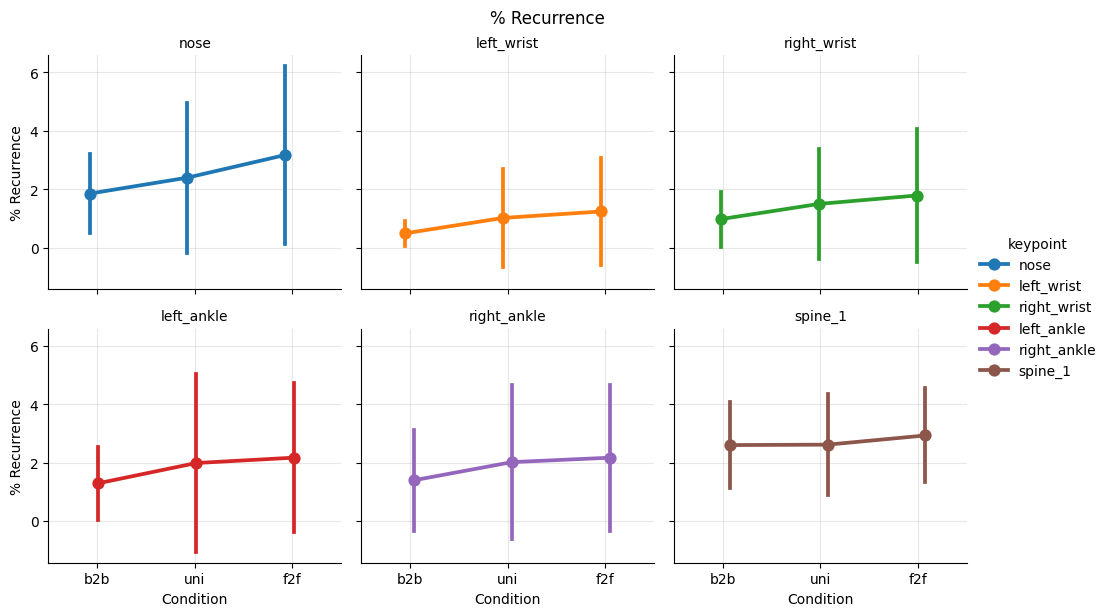

/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_38109/1698316273.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  g = sns.catplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_38109/1698316273.py:25: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  g = sns.catplot(


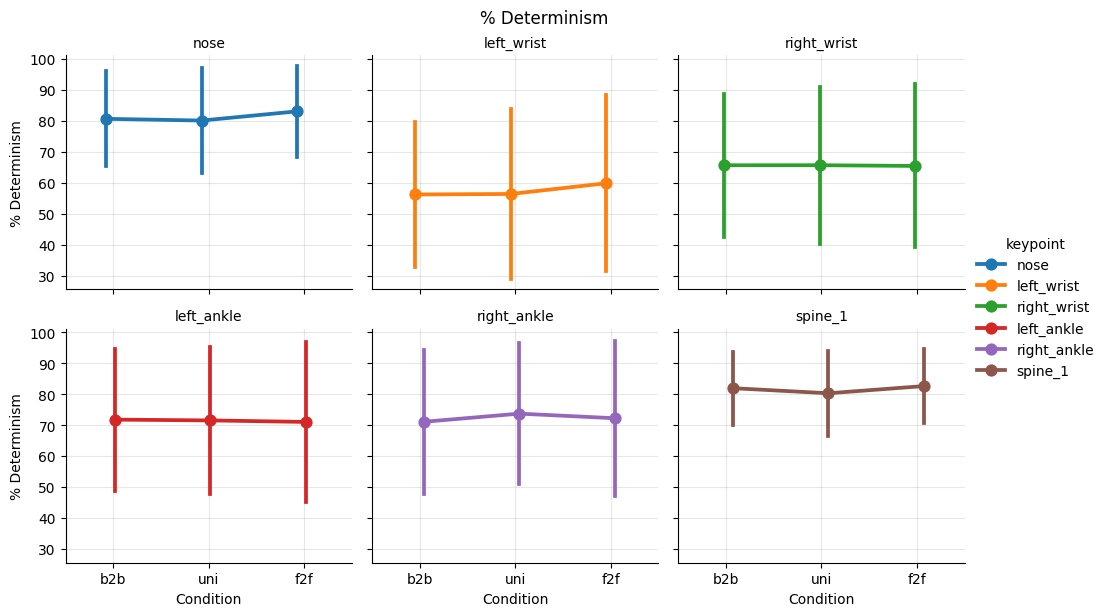

/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_38109/1698316273.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  g = sns.catplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_38109/1698316273.py:25: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  g = sns.catplot(


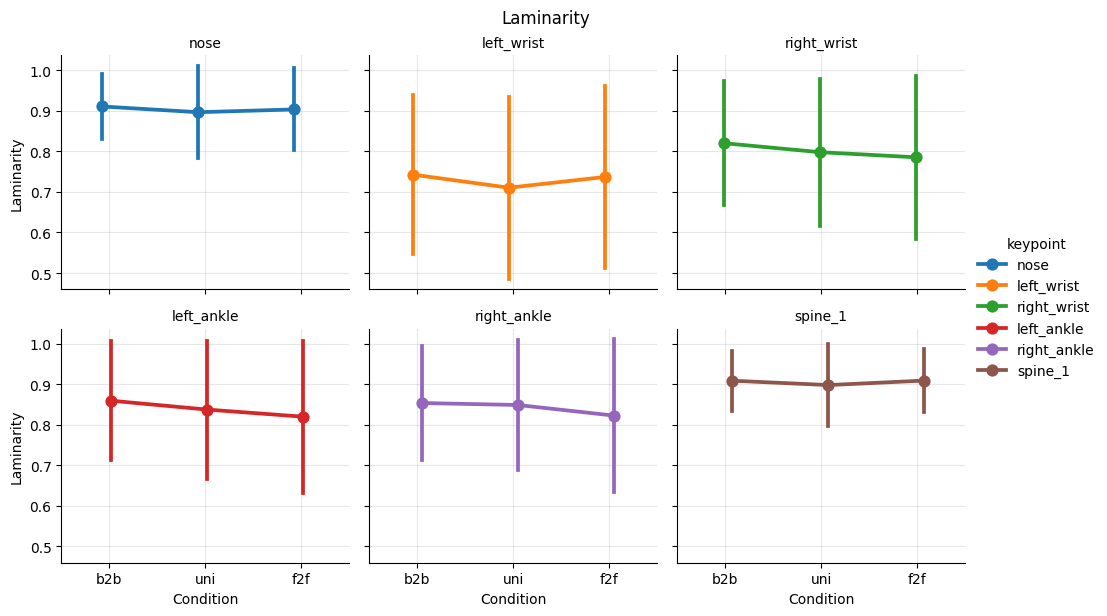

/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_38109/1698316273.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  g = sns.catplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_38109/1698316273.py:25: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  g = sns.catplot(


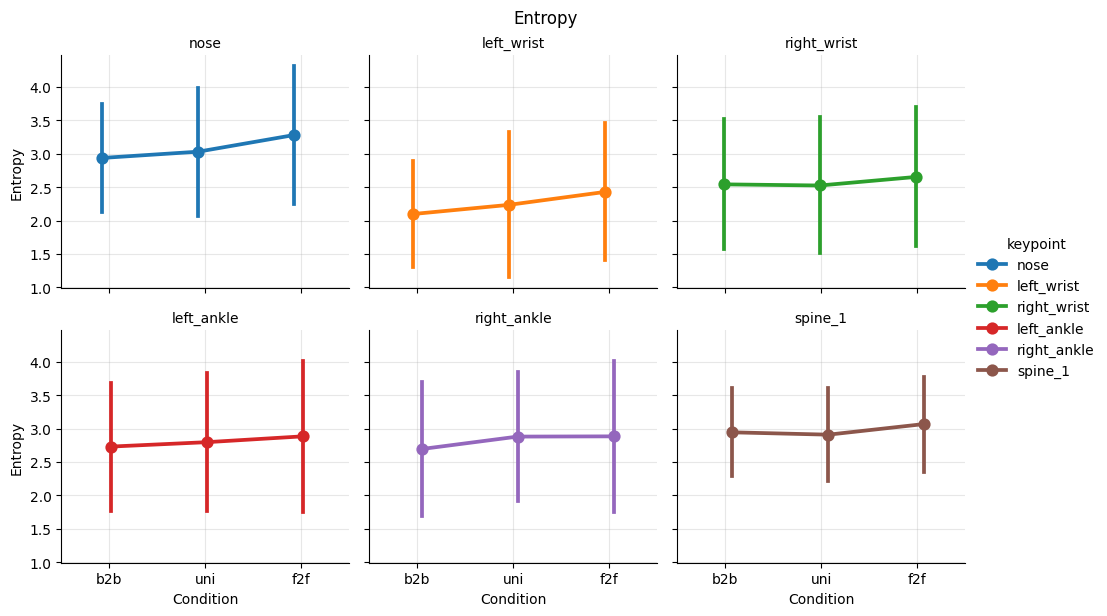

/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_38109/1698316273.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  g = sns.catplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_38109/1698316273.py:25: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  g = sns.catplot(


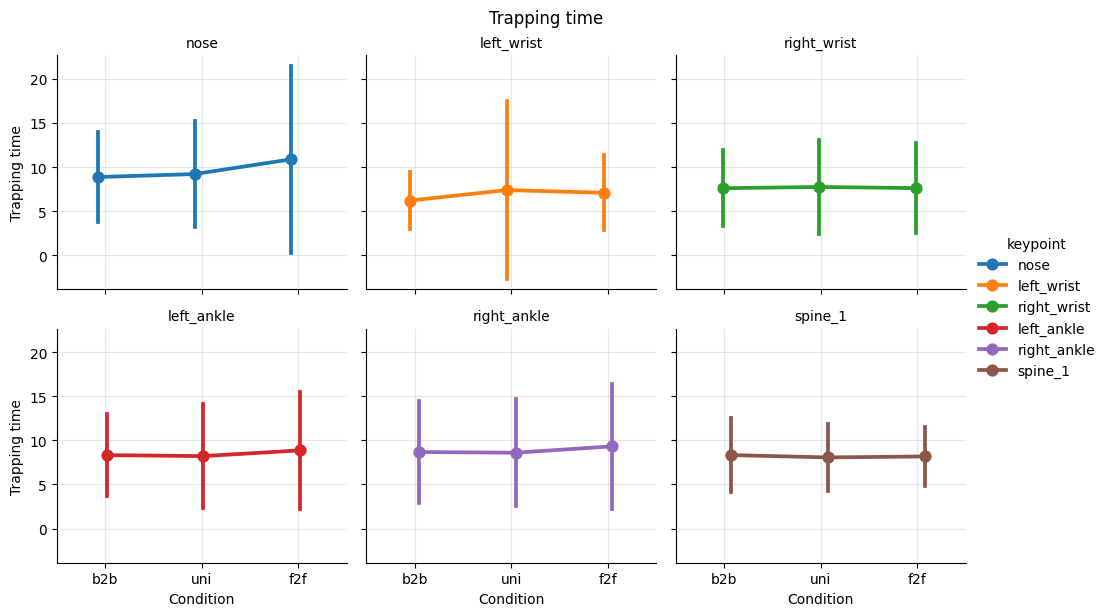

/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_38109/1698316273.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  g = sns.catplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_38109/1698316273.py:25: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  g = sns.catplot(


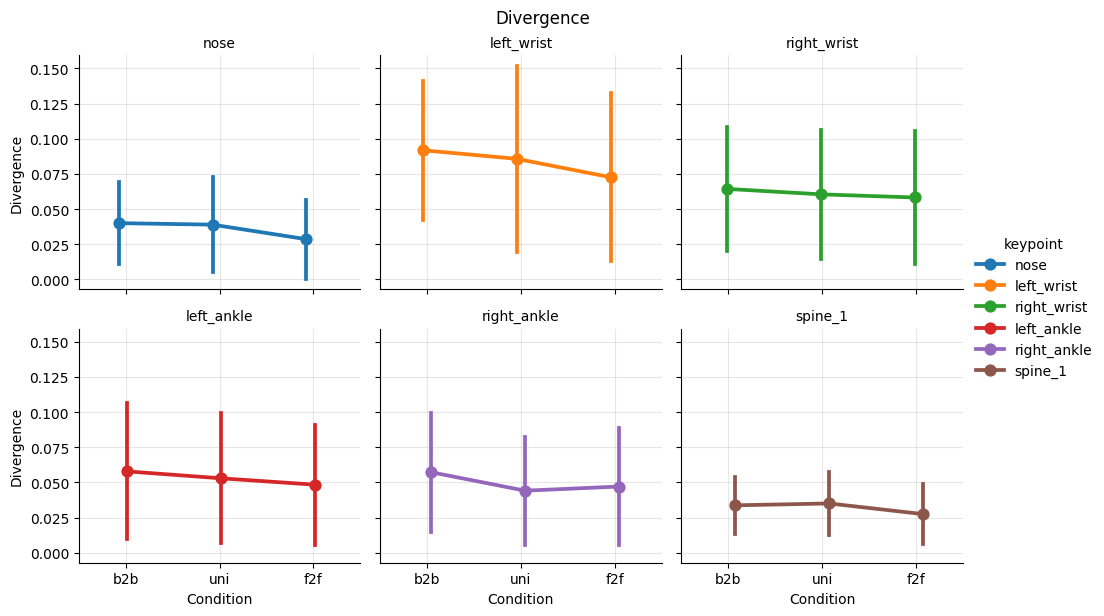

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

CRQA_METRICS = [
    "perc_recur",
    "perc_determ",
    "laminarity",
    "entropy",
    "trapping_time",
    "divergence",
]

METRIC_LABELS = {
    "perc_recur":      "% Recurrence",
    "perc_determ":     "% Determinism",
    "laminarity":      "Laminarity",
    "entropy":         "Entropy",
    "trapping_time":   "Trapping time",
    "divergence":      "Divergence",
}

COND_ORDER = ["b2b", "uni", "f2f"]

def plot_crqa_metric_by_keypoint(df, metric, save_path=None):
    g = sns.catplot(
        data=df,
        x="Condition",
        y=metric,
        hue="keypoint",
        col="keypoint",
        kind="point",          # points + lines
        dodge=True,
        ci="sd",
        join=True,
        order=COND_ORDER,
        col_wrap=3,
        height=3.0,
        aspect=1.1
    )
    g.set_titles(col_template="{col_name}")
    g.set_axis_labels("Condition", METRIC_LABELS.get(metric, metric))
    for ax in g.axes.flatten():
        ax.grid(alpha=0.3)

    g.fig.suptitle(METRIC_LABELS.get(metric, metric), y=1.02)

    if save_path is not None:
        g.fig.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

for metric in CRQA_METRICS:
    plot_crqa_metric_by_keypoint(
        crqa_merged,
        metric,
        save_path=OUT_DIR / f"crqa_{metric}_by_keypoint.png"
    )



## 8. Multivariate Recurrence

In [115]:
from pose_dynamics.rqa.multivariateRQA import multivariateCrossRQA

TARGET_KP = ["nose", "left_wrist", "right_wrist", 
             "left_ankle", "right_ankle", "spine_1"]

multi_pairs = {}   

for (pair_trial, kp_name), parties in paired_kp.items():
    if pair_trial not in multi_pairs:
        multi_pairs[pair_trial] = {"P1": [], "P2": []}
    
    if kp_name in TARGET_KP:
        if "P1" in parties and "P2" in parties:
            multi_pairs[pair_trial]["P1"].append(parties["P1"])
            multi_pairs[pair_trial]["P2"].append(parties["P2"])

for pair_trial, d in multi_pairs.items():
    d["P1"] = np.column_stack(d["P1"])
    d["P2"] = np.column_stack(d["P2"])

MdCRQA_RESULTS = []

params_mdrqa = {
    "norm":        "zscore",
    "rescaleNorm": 1,
    "radius":      0.20,      # multivariate radius (tunable)
    "minl":        3,
    "tw":          0,
    "plotMode":    "none",
    "pointSize":   1,
    "showMetrics": False,
    "saveFig":     False,
    "doStatsFile": False,
}

for pair_trial, parties in multi_pairs.items():
    if "P1" not in parties or "P2" not in parties:
        continue
    
    data1 = parties["P1"]
    data2 = parties["P2"]
    
    # match lengths
    T = min(data1.shape[0], data2.shape[0])
    data1 = data1[:T]
    data2 = data2[:T]
    
    td, rs, mats, err = multivariateCrossRQA(
        data1,
        data2,
        params_mdrqa
    )
    
    if err != 0:
        print(f"⚠️ MdCRQA error on {pair_trial}")
        continue
    
    MdCRQA_RESULTS.append({
        "pair_trial": pair_trial,
        **{k: float(v) for k, v in rs.items()}
    })

md_df = pd.DataFrame(MdCRQA_RESULTS)
print(md_df.head())

md_out = OUT_DIR / "mdcrqa_results.csv"
md_df.to_csv(md_out, index=False)
print(f"✓ Saved: {md_out}")


  pair_trial  rescale  rad  diag_ignore  minl  perc_recur  perc_determ  \
0   P001_T10      1.0  0.2          0.0   3.0    1.603424    89.523038   
1   P001_T11      1.0  0.2          0.0   3.0    1.856954    94.949743   
2   P001_T12      1.0  0.2          0.0   3.0    0.132839    66.971188   
3    P001_T1      1.0  0.2          0.0   3.0    0.290433    86.988619   
4    P001_T2      1.0  0.2          0.0   3.0    0.415130    88.903567   

        npts   entropy  complexity  ...  maxl_found  trend_lower_diag  \
0  1077444.0  3.767229    6.249579  ...        31.0         -2.537496   
1  1098304.0  4.448751    5.581916  ...        43.0         -2.164573   
2  1071225.0  2.678378    7.334247  ...        16.0         -0.066167   
3  1119364.0  3.163185    6.881209  ...        14.0          0.579609   
4  1094116.0  3.564964    6.462942  ...        38.0         -0.802014   

   trend_upper_diag  mean_line_length  std_line_length  count_line  \
0          0.743581          7.675434         

### Statistics

In [116]:
from pose_dynamics.linear_features_utils import merge_with_conditions

# Add dummy columns so the merge helper works
md_df['party'] = 'P1'
md_df['trial_index'] = 0

mdcrqa_merged = merge_with_conditions(
    features_df=md_df,
    conditions_csv=CONDITIONS_CSV,
    verbose=True
)

print(mdcrqa_merged.head())
print(mdcrqa_merged.columns)

CRQA_METRICS = [
    "perc_recur",
    "perc_determ",
    "laminarity",
    "entropy",
    "trapping_time",
    "divergence",
]

desc_md = mdcrqa_merged.groupby("Condition")[CRQA_METRICS].agg(["mean", "std", "count"])
print(desc_md.round(3))

import statsmodels.formula.api as smf

mdcrqa_merged["Pair"] = mdcrqa_merged["Pair"].astype("category")
mdcrqa_merged["Condition"] = mdcrqa_merged["Condition"].astype("category")

for metric in CRQA_METRICS:
    print("\n" + "="*80)
    print(f"MIXED MODEL FOR MdCRQA {metric.upper()} ~ Condition")
    print("="*80)
    
    model = smf.mixedlm(
        f"{metric} ~ C(Condition)",
        data=mdcrqa_merged,
        groups=mdcrqa_merged["Pair"]
    )
    result = model.fit()
    print(result.summary())

from statsmodels.stats.multicomp import pairwise_tukeyhsd

for metric in CRQA_METRICS:
    print("\n" + "-"*80)
    print(f"Tukey posthoc for MdCRQA {metric.upper()} (Condition)")
    print("-"*80)
    
    tuk = pairwise_tukeyhsd(
        endog=mdcrqa_merged[metric],
        groups=mdcrqa_merged["Condition"],
        alpha=0.05
    )
    print(tuk)




Merge summary:
  Rows before: 216
  Rows after:  216
  Conditions:  ['uni' 'f2f' 'b2b']
  Roles:       ['Follower' 'Leader']
  pair_trial  rescale  rad  diag_ignore  minl  perc_recur  perc_determ  \
0   P001_T10      1.0  0.2          0.0   3.0    1.603424    89.523038   
1   P001_T11      1.0  0.2          0.0   3.0    1.856954    94.949743   
2   P001_T12      1.0  0.2          0.0   3.0    0.132839    66.971188   
3    P001_T1      1.0  0.2          0.0   3.0    0.290433    86.988619   
4    P001_T2      1.0  0.2          0.0   3.0    0.415130    88.903567   

        npts   entropy  complexity  ...  trapping_time  vmax  divergence  \
0  1077444.0  3.767229    6.249579  ...      10.767798  40.0    0.032258   
1  1098304.0  4.448751    5.581916  ...      17.150427  50.0    0.023256   
2  1071225.0  2.678378    7.334247  ...       6.004975  26.0    0.062500   
3  1119364.0  3.163185    6.881209  ...       7.520885  30.0    0.071429   
4  1094116.0  3.564964    6.462942  ...      11.2

/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
   b2b    f2f   6.0634 0.3498   -4.258 16.3848  False
   b2b    uni    3.166 0.7496  -7.1554 13.4874  False
   f2f    uni  -2.8974 0.7854 -13.2188   7.424  False
-----------------------------------------------------

--------------------------------------------------------------------------------
Tukey posthoc for MdCRQA LAMINARITY (Condition)
--------------------------------------------------------------------------------
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   b2b    f2f   0.0047 0.9906 -0.0796 0.0889  False
   b2b    uni   0.0044 0.9916 -0.0798 0.0887  False
   f2f    uni  -0.0003    1.0 -0.0845  0.084  False
---------------------------------------------------

----------------------------------------------

### Figures

/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_38109/2417953291.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.pointplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_38109/2417953291.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.pointplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_38109/2417953291.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.pointplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_38109/2417953291.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.pointplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_38109/2417953291.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.pointplot(
/var/folders/fg/dc68zxv12sz5v55n18s

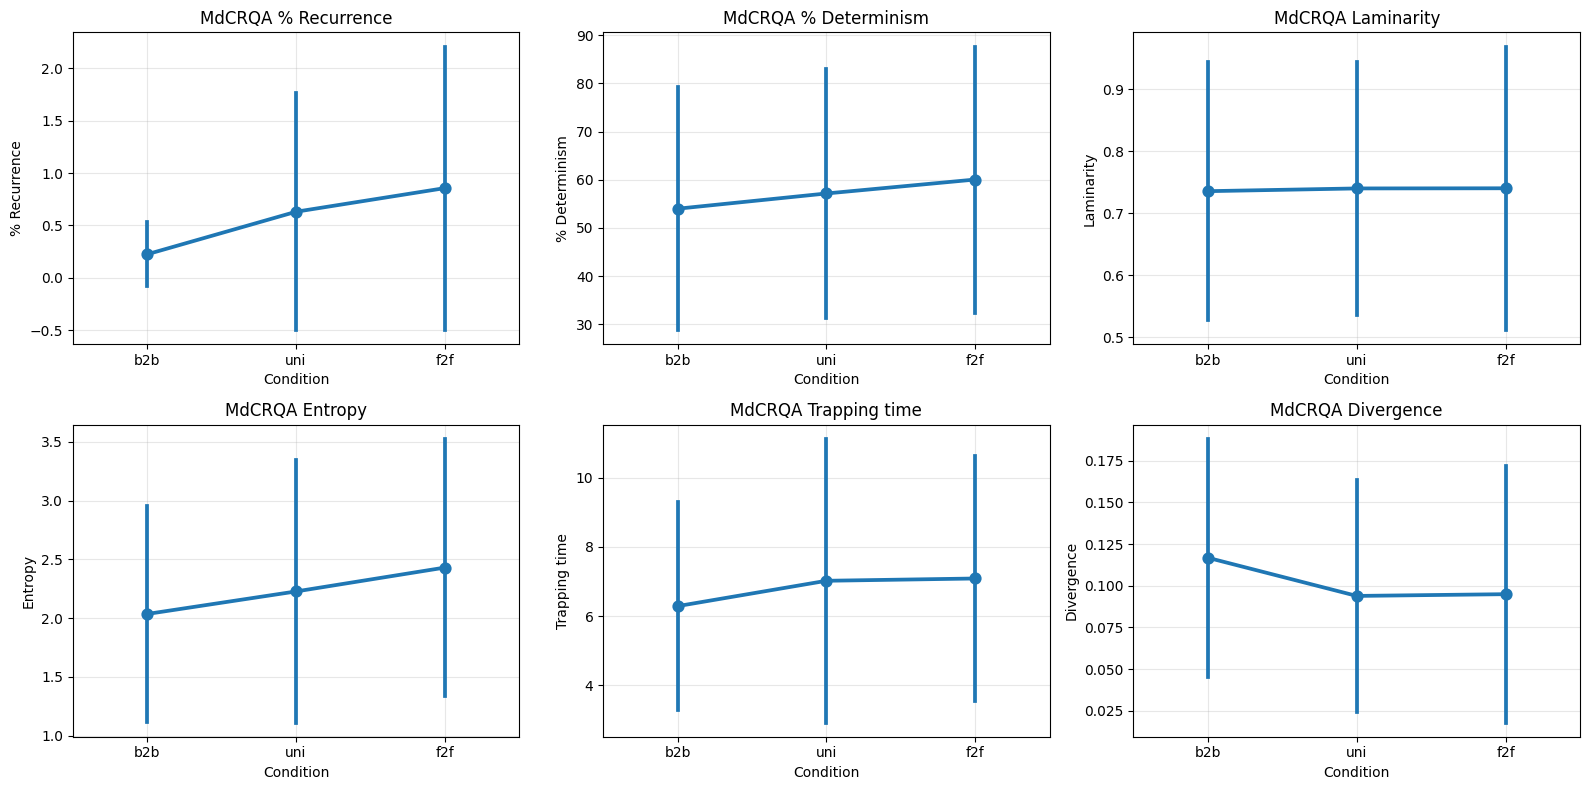

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

COND_ORDER = ["b2b", "uni", "f2f"]
METRIC_LABELS = {
    "perc_recur":    "% Recurrence",
    "perc_determ":   "% Determinism",
    "laminarity":    "Laminarity",
    "entropy":       "Entropy",
    "trapping_time": "Trapping time",
    "divergence":    "Divergence",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, metric in zip(axes, CRQA_METRICS):
    sns.pointplot(
        data=mdcrqa_merged,
        x="Condition",
        y=metric,
        order=COND_ORDER,
        ci="sd",
        ax=ax
    )
    ax.set_title(f"MdCRQA {METRIC_LABELS.get(metric, metric)}")
    ax.set_xlabel("Condition")
    ax.set_ylabel(METRIC_LABELS.get(metric, metric))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
